# 📊 SARIMAX **v9.1** — KWh Harian Firebase PZEM-004T
**Sistem Monitoring Energi | Skripsi**

| # | Perubahan dari v8 |
|---|---|
| 1 | ✅ **Grid search benar 64 kombinasi** — P/Q dikembalikan ke [0,1] sesuai desain |
| 2 | ✅ **enforce_stationarity=True dulu**, fallback ke False jika fitting gagal |
| 3 | ✅ **Horizon guard** — skip h > n_test agar tidak evaluasi data imajiner |
| 4 | ✅ **flag_aktif diekspor benar** untuk RL (tidak di-hardcode 1.0) |
| 5 | ✅ **Cell 14 — RL Export**: broadcast kWh→Watt hourly + gap formula ×24 jam |
| 6 | ✅ **Watt range Magicom dikoreksi** 280–380 W (bukan 100–220 W) |
| 7 | ✅ **Split 70/30** (bukan 80/20) — sesuai permintaan |
| 8 | ✅ **144 kombinasi grid search** — Q & SQ diperluas ke [0,1,2] |
| 9 | ✅ **DEVICE_RANGES diupdate** dari kalibrasi aktual AC 314-587W / Magicom 280-315W / WH 210-285W / TV 26-60W / Laptop 12-48W |


## 🔗 Jalankan notebook ini SEBELUM RL_Budget_Energy_v10

**Output wajib yang dibutuhkan RL notebook:**
1. `Cell 13` → `/content/drive/MyDrive/data/sarimax_model_for_rl.pkl`
2. `Cell 14` → `/content/drive/MyDrive/data/df_rl_forecast_v9.csv`

Lihat tabel integrasi lengkap di **RL_Budget_Energy_v10.ipynb → cell ke-3**.


In [2]:
START_DATE  = "2026-03-05"
END_DATE    = "2026-04-04"
TRAIN_RATIO = 0.70
KWH_AKTIF_THRESHOLD = 0.1


TARIF_KWH         = 1352.0   # Rp/kWh  — Golongan R-1/900VA non-subsidi
DEFAULT_BUDGET    = 15_000.0 # Rp/bulan — sesuai RL v10
BUDGET_HARIAN_RP  = DEFAULT_BUDGET / 30  # ≈ 500 Rp/hari

M = 7

# v9-fix: Q & SQ diperluas ke [0,1,2] → 2×2×3×2×2×3 = 144 kombinasi
P_RANGE  = [0, 1];  D_RANGE  = [0, 1];  Q_RANGE  = [0, 1, 2]
SP_RANGE = [0, 1];  SD_RANGE = [0, 1];  SQ_RANGE = [0, 1, 2]


DEVICE_RANGES = {
    "ac":      (314,  587),   # AC — Kompresor menyala (beban berat)
    "magicom": (280,  315),   # Magicom — Mode memasak (beban berat)
    "wh":      (210,  285),   # Water Heater — Elemen pemanas aktif
    "tv":      ( 26,   60),   # TV — Menyala aktif
    "laptop":  ( 12,   48),   # Laptop — Digunakan / Charging
}

IDLE_THRESHOLD_W = 12   # watt — di bawah ini = idle/standby (Laptop min 12W)

print("⚙️  Konfigurasi v9:")
print(f"   START_DATE  : {START_DATE}")
print(f"   END_DATE    : {END_DATE}")
print(f"   Train ratio : {TRAIN_RATIO*100:.0f}% / {(1-TRAIN_RATIO)*100:.0f}%")
print(f"   kWh thr     : {KWH_AKTIF_THRESHOLD} kWh/hari")
print(f"   Seasonality : M={M} (mingguan)")
from itertools import product as _prod
_n_grid = len(list(_prod(P_RANGE, D_RANGE, Q_RANGE, SP_RANGE, SD_RANGE, SQ_RANGE)))
print(f"   Grid search : {_n_grid} kombinasi  (Q/SQ=[0,1,2] → 2×2×3×2×2×3={_n_grid})")
print(f"   AC      : {DEVICE_RANGES['ac'][0]}–{DEVICE_RANGES['ac'][1]} W (kompresor)")
print(f"   Magicom : {DEVICE_RANGES['magicom'][0]}–{DEVICE_RANGES['magicom'][1]} W (memasak)")
print(f"   WH      : {DEVICE_RANGES['wh'][0]}–{DEVICE_RANGES['wh'][1]} W (elemen pemanas)")
print(f"   TV      : {DEVICE_RANGES['tv'][0]}–{DEVICE_RANGES['tv'][1]} W (aktif)")
print(f"   Laptop  : {DEVICE_RANGES['laptop'][0]}–{DEVICE_RANGES['laptop'][1]} W (charging)")
print(f"   Idle    : < {IDLE_THRESHOLD_W} W")


⚙️  Konfigurasi v9:
   START_DATE  : 2026-03-05
   END_DATE    : 2026-04-04
   Train ratio : 70% / 30%
   kWh thr     : 0.1 kWh/hari
   Seasonality : M=7 (mingguan)
   Grid search : 144 kombinasi  (Q/SQ=[0,1,2] → 2×2×3×2×2×3=144)
   AC      : 314–587 W (kompresor)
   Magicom : 280–315 W (memasak)
   WH      : 210–285 W (elemen pemanas)
   TV      : 26–60 W (aktif)
   Laptop  : 12–48 W (charging)
   Idle    : < 12 W


## Cell 1 — Install & Import

In [3]:
!pip install statsmodels scipy scikit-learn firebase-admin --quiet
print("✅ Dependencies installed")

✅ Dependencies installed


In [4]:
import json, os, warnings, platform, importlib.metadata
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats as sp_stats
from scipy.stats import chi2, boxcox, boxcox_normmax
from scipy.special import inv_boxcox
from itertools import product

warnings.filterwarnings("ignore")

C = {
    "blue":"#0969da", "amber":"#b45309", "green":"#15803d",
    "red":"#dc2626",  "purple":"#7c3aed", "teal":"#0d9488",
    "gray":"#57606a", "bg":"#ffffff",    "bg2":"#f0f4f8",
}
plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "text.color":"#1f2328",    "axes.edgecolor":C["gray"],
    "axes.labelcolor":C["gray"], "xtick.color":C["gray"],
    "ytick.color":C["gray"],   "grid.color":"#d0d7de",
    "grid.linewidth":0.6,      "font.family":"monospace",
    "axes.spines.top":False,   "axes.spines.right":False,
})

OUT = Path("validasi_output_v9"); OUT.mkdir(exist_ok=True)

def to_arr(fc):   return np.array(fc).flatten()
def calc_mae(a, b):  return float(np.mean(np.abs(np.array(a) - np.array(b))))
def calc_rmse(a, b): return float(np.sqrt(np.mean((np.array(a) - np.array(b))**2)))

def calc_mape(a, b, threshold=KWH_AKTIF_THRESHOLD):
    a, b = np.array(a), np.array(b)
    mask = a > threshold
    if not mask.any(): return None
    return float(np.mean(np.abs((a[mask] - b[mask]) / a[mask])) * 100)

print(f"✅ Import selesai | Output: {OUT.resolve()}")

✅ Import selesai | Output: /content/validasi_output_v9


## Cell 2 — Load Data Firebase

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Load JSON export dari Google Drive
# ══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

_JSON_PATH = "/content/drive/MyDrive/data/test-reading-the-pzem-default-rtdb-export (10).json"

with open(_JSON_PATH, "r", encoding="utf-8") as _f:
    RAW_DATA = json.load(_f)

DATA_MODE = "json_export"
print(f"✅ Dimuat dari Drive: {_JSON_PATH}")
print(f"   Top-level keys: {list(RAW_DATA.keys())}")

Mounted at /content/drive
✅ Dimuat dari Drive: /content/drive/MyDrive/data/test-reading-the-pzem-default-rtdb-export (10).json
   Top-level keys: ['Evaluasi_Model_SARIMAX', 'Hasil_AI', 'Kwh_Jam', 'Monitoring', 'dashboard_info', 'history', 'log_konfirmasi', 'rekap_harian', 'user_confirmation', 'user_preferences']


## Cell 3 — Preprocessing kWh Harian (dari rekap_harian)

Rekap harian mentah : 68 hari
   kWh range: 0.000 – 3.907
   kWh nol  : 20 hari
   kWh NaN  : 0 hari
✅ Filter dari 2026-03-05 → 67 hari
✅ Filter s/d 2026-04-04 → 31 hari

   Rentang : 2026-03-05 → 2026-04-04
   Total   : 31 hari
   Aktif   : 31 hari  Mati: 0 hari
   Weekend : 9 hari  Weekday: 22 hari


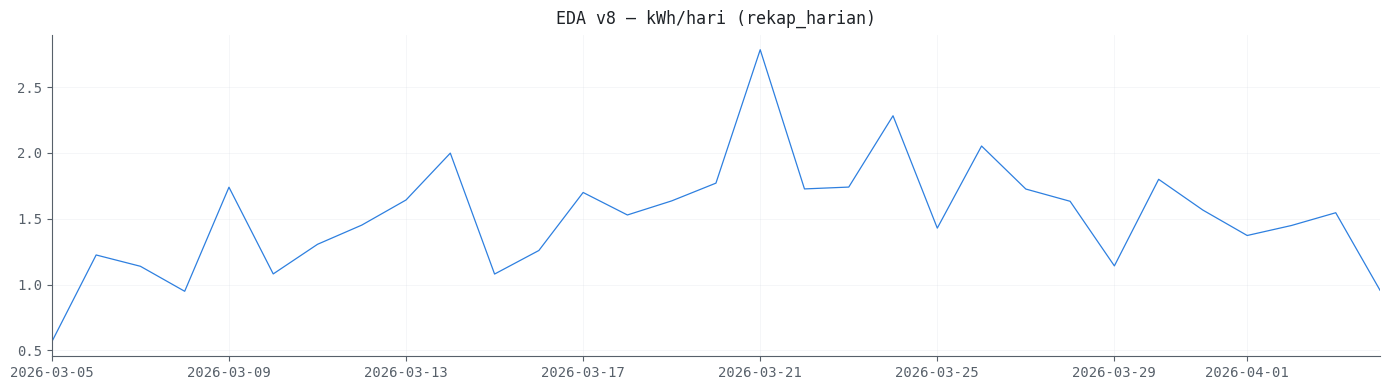

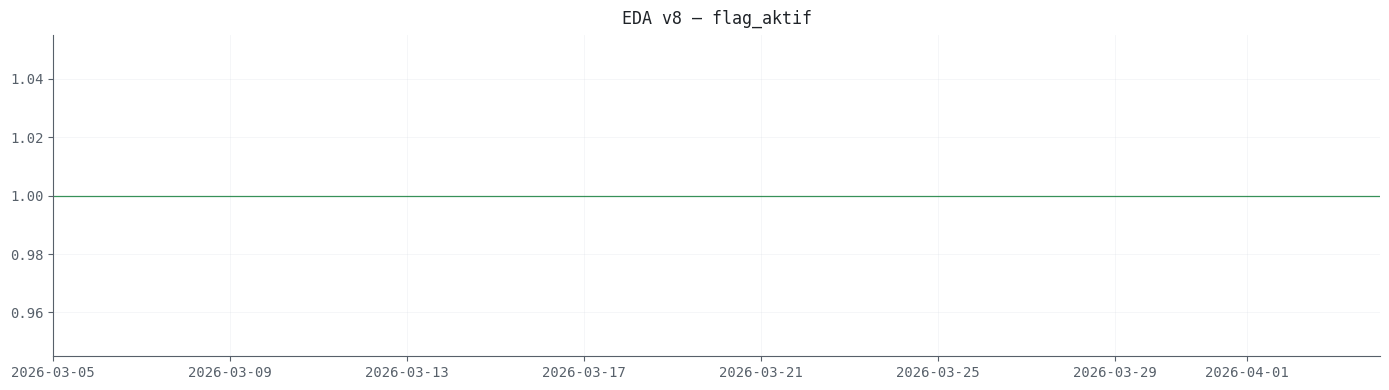

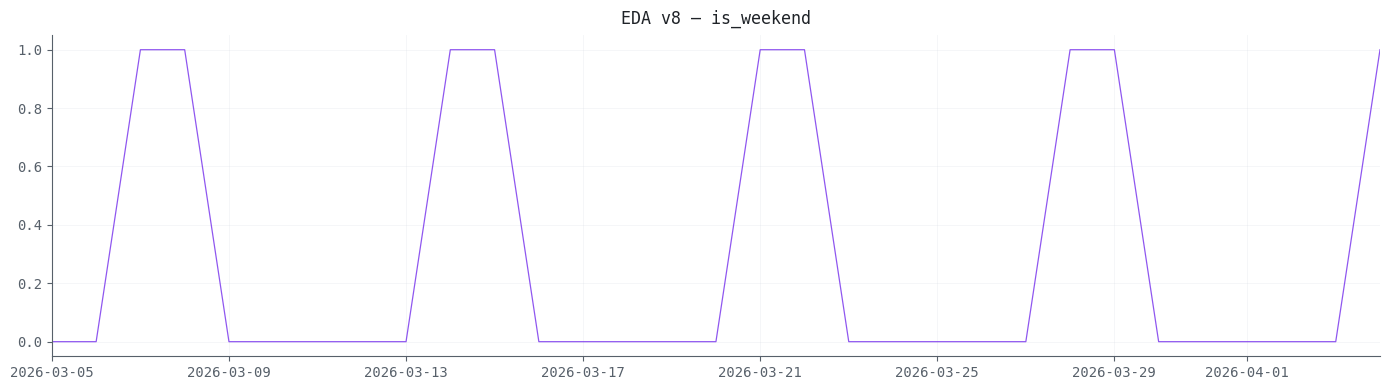

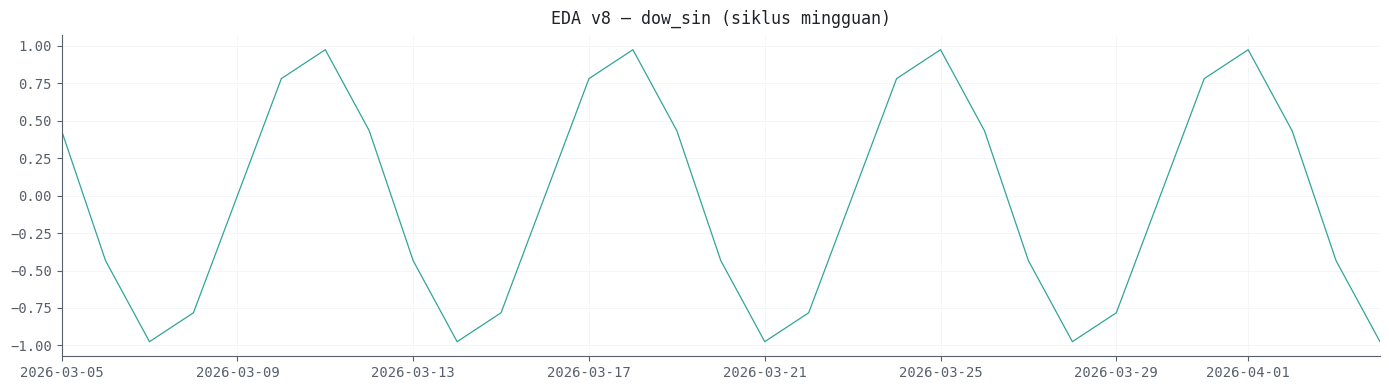

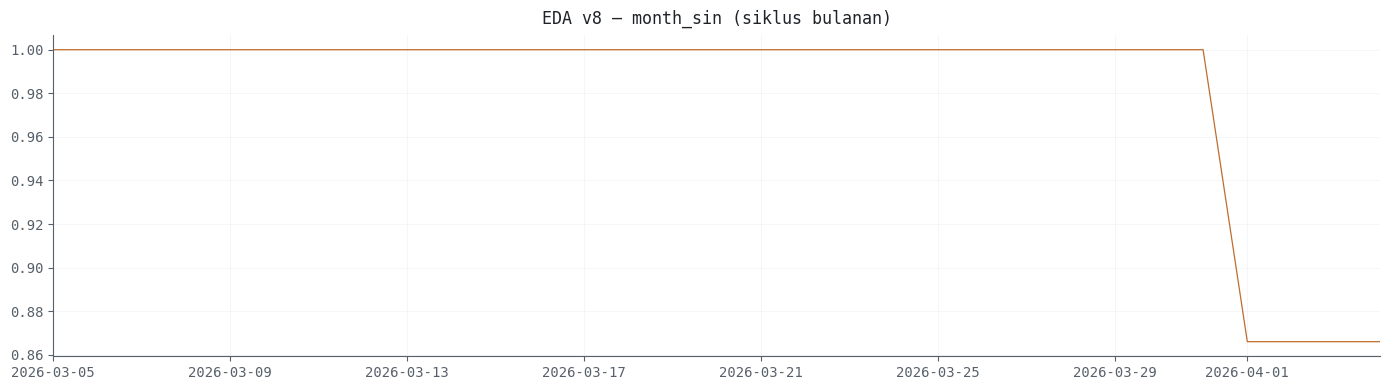

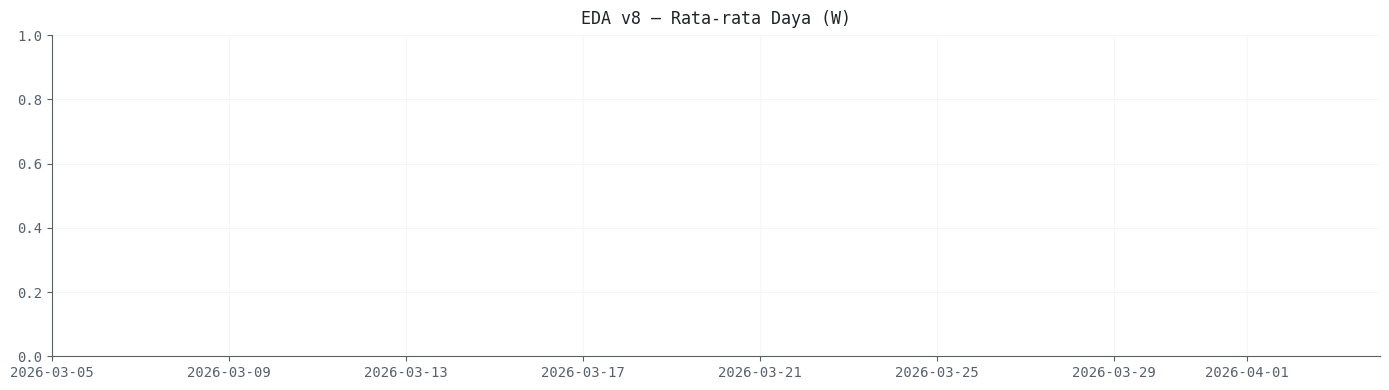

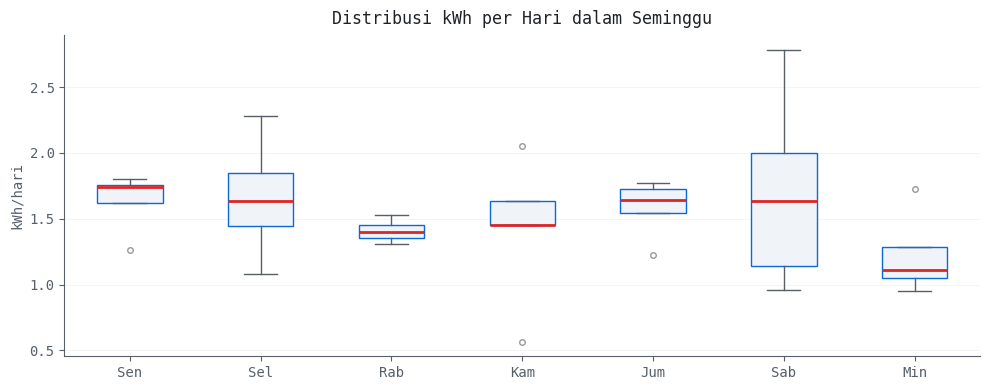

💾 00b_kwh_per_dow.png


In [6]:
# ══════════════════════════════════════════════════════════════════════
# SUMBER DATA UTAMA: rekap_harian.history  (bukan history per menit)
# Setiap record: {"penggunaan_kwh": X, "rata_rata_daya": Y, ...}
# ══════════════════════════════════════════════════════════════════════

rekap_raw = RAW_DATA.get("rekap_harian", {}).get("history", {})
if not rekap_raw:
    raise ValueError("❌ Node 'rekap_harian.history' tidak ditemukan di JSON!")

rows = []
for tanggal_str, val in rekap_raw.items():
    if not isinstance(val, dict): continue
    try:
        kwh = float(val.get("penggunaan_kwh", None))
        rows.append({
            "tanggal": pd.Timestamp(tanggal_str, tz="Asia/Jakarta"),
            "kwh":     kwh,
            "kwh_raw": kwh,
            # kolom tambahan jika tersedia
            "rata_daya_W": float(val.get("rata_rata_daya", np.nan)),
        })
    except (TypeError, ValueError):
        pass

df_daily = pd.DataFrame(rows).sort_values("tanggal").set_index("tanggal")
df_daily = df_daily[~df_daily.index.duplicated(keep="last")]  # hapus duplikat

print(f"Rekap harian mentah : {len(df_daily)} hari")
print(f"   kWh range: {df_daily['kwh'].min():.3f} – {df_daily['kwh'].max():.3f}")
print(f"   kWh nol  : {(df_daily['kwh']==0).sum()} hari")
print(f"   kWh NaN  : {df_daily['kwh'].isna().sum()} hari")

# ── Filter tanggal ──────────────────────────────────────────────────────────
_range_start = pd.Timestamp(START_DATE, tz="Asia/Jakarta") if START_DATE else df_daily.index[0]
_range_end   = pd.Timestamp(END_DATE,   tz="Asia/Jakarta") if END_DATE   else df_daily.index[-1]

if START_DATE:
    df_daily = df_daily[df_daily.index >= _range_start]
    print(f"✅ Filter dari {START_DATE} → {len(df_daily)} hari")
if END_DATE:
    df_daily = df_daily[df_daily.index <= _range_end + pd.Timedelta("23h59m")]
    print(f"✅ Filter s/d {END_DATE} → {len(df_daily)} hari")

# ── Isi hari yang hilang (reindex kalender, interpolasi linear) ─────────────
full_idx  = pd.date_range(df_daily.index[0], df_daily.index[-1], freq="D", tz="Asia/Jakarta")
df_daily  = df_daily.reindex(full_idx)
n_missing = df_daily["kwh"].isna().sum()
if n_missing:
    df_daily["kwh"] = df_daily["kwh"].interpolate("linear")
    print(f"   Hari hilang (interpolasi): {n_missing}")

# ── Flag hari mati (kwh == 0 dari rekap atau flag eksplisit) ───────────────
dead_days = {
    d for d, v in rekap_raw.items()
    if isinstance(v, dict) and float(v.get("penggunaan_kwh", 1)) == 0
    and _range_start.date() <= pd.Timestamp(d).date() <= _range_end.date()
}
df_daily["flag_aktif"] = (~df_daily.index.strftime("%Y-%m-%d").isin(dead_days)).astype(int)

# ── Fitur temporal ─────────────────────────────────────────────────────────
df_daily["dow"]       = df_daily.index.dayofweek          # 0=Senin, 6=Minggu
df_daily["is_weekend"]= (df_daily["dow"] >= 5).astype(int)
df_daily["month"]     = df_daily.index.month
df_daily["dow_sin"]   = np.sin(2 * np.pi * df_daily["dow"]   / 7)
df_daily["dow_cos"]   = np.cos(2 * np.pi * df_daily["dow"]   / 7)
df_daily["month_sin"] = np.sin(2 * np.pi * df_daily["month"] / 12)
df_daily["month_cos"] = np.cos(2 * np.pi * df_daily["month"] / 12)

print(f"\n   Rentang : {df_daily.index[0].date()} → {df_daily.index[-1].date()}")
print(f"   Total   : {len(df_daily)} hari")
print(f"   Aktif   : {df_daily['flag_aktif'].sum()} hari  "
      f"Mati: {(df_daily['flag_aktif']==0).sum()} hari")
print(f"   Weekend : {df_daily['is_weekend'].sum()} hari  "
      f"Weekday: {(df_daily['is_weekend']==0).sum()} hari")

# ── EDA Plot — Grafik Terpisah ──────────────────────────────────────────
_xlim = (df_daily.index[0], df_daily.index[-1])

plots = [
    ("kwh",        C["blue"],   "kWh/hari"),
    ("flag_aktif", C["green"],  "flag_aktif"),
    ("is_weekend", C["purple"], "is_weekend"),
    ("dow_sin",    C["teal"],   "dow_sin (siklus mingguan)"),
    ("month_sin",  C["amber"],  "month_sin (siklus bulanan)"),
    ("rata_daya_W",C["gray"],   "Rata-rata Daya (W) — tambahan"),
]

fig_titles = [
    "EDA v8 — kWh/hari (rekap_harian)",
    "EDA v8 — flag_aktif",
    "EDA v8 — is_weekend",
    "EDA v8 — dow_sin (siklus mingguan)",
    "EDA v8 — month_sin (siklus bulanan)",
    "EDA v8 — Rata-rata Daya (W)",
]

for (col, col2, lbl), title in zip(plots, fig_titles):
    fig, ax = plt.subplots(figsize=(14, 4), facecolor="white")
    ax.set_facecolor("white")
    if col in df_daily.columns and df_daily[col].notna().any():
        ax.plot(df_daily.index, df_daily[col], color=col2, lw=0.9, alpha=0.85)
    ax.set_title(title, color="#1f2328", pad=8)
    ax.set_xlim(_xlim); ax.grid(True, alpha=0.25)
    for dd in dead_days:
        try:
            ax.axvspan(pd.Timestamp(dd, tz="Asia/Jakarta"),
                       pd.Timestamp(dd, tz="Asia/Jakarta") + pd.Timedelta("1D"),
                       alpha=0.12, color=C["red"])
        except: pass
    plt.tight_layout()
    plt.show()

# ── Boxplot per hari dalam seminggu ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4), facecolor="white")
ax.set_facecolor("white")
dow_labels = ["Sen","Sel","Rab","Kam","Jum","Sab","Min"]
data_per_dow = [df_daily[df_daily["dow"]==d]["kwh"].dropna().values for d in range(7)]
bp = ax.boxplot(data_per_dow, patch_artist=True,
                boxprops=dict(facecolor=C["bg2"], color=C["blue"]),
                medianprops=dict(color=C["red"], lw=2),
                whiskerprops=dict(color=C["gray"]),
                capprops=dict(color=C["gray"]),
                flierprops=dict(marker="o", color=C["amber"], alpha=0.4, ms=4))
ax.set_xticklabels(dow_labels)
ax.set_title("Distribusi kWh per Hari dalam Seminggu", color="#1f2328", pad=8)
ax.set_ylabel("kWh/hari"); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show(); print("💾 00b_kwh_per_dow.png")

## Cell 4 — Split 70/30 (Train / Test) — Unit: kWh/hari

════════════════════════════════════════════════════════════
  SPLIT 70/30 — Kronologis (unit: kWh/hari)
════════════════════════════════════════════════════════════
  Train :   21 hari  67.7%
          2026-03-05 → 2026-03-25
          kWh mean=1.526  std=0.471
          Hari aktif: 100.0%
  Test  :   10 hari  32.3%
          2026-03-26 → 2026-04-04
          kWh mean=1.525  std=0.301
          Hari aktif: 100.0%
════════════════════════════════════════════════════════════

Exog: ['flag_aktif', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
Shape — train:(21, 6)  test:(10, 6)


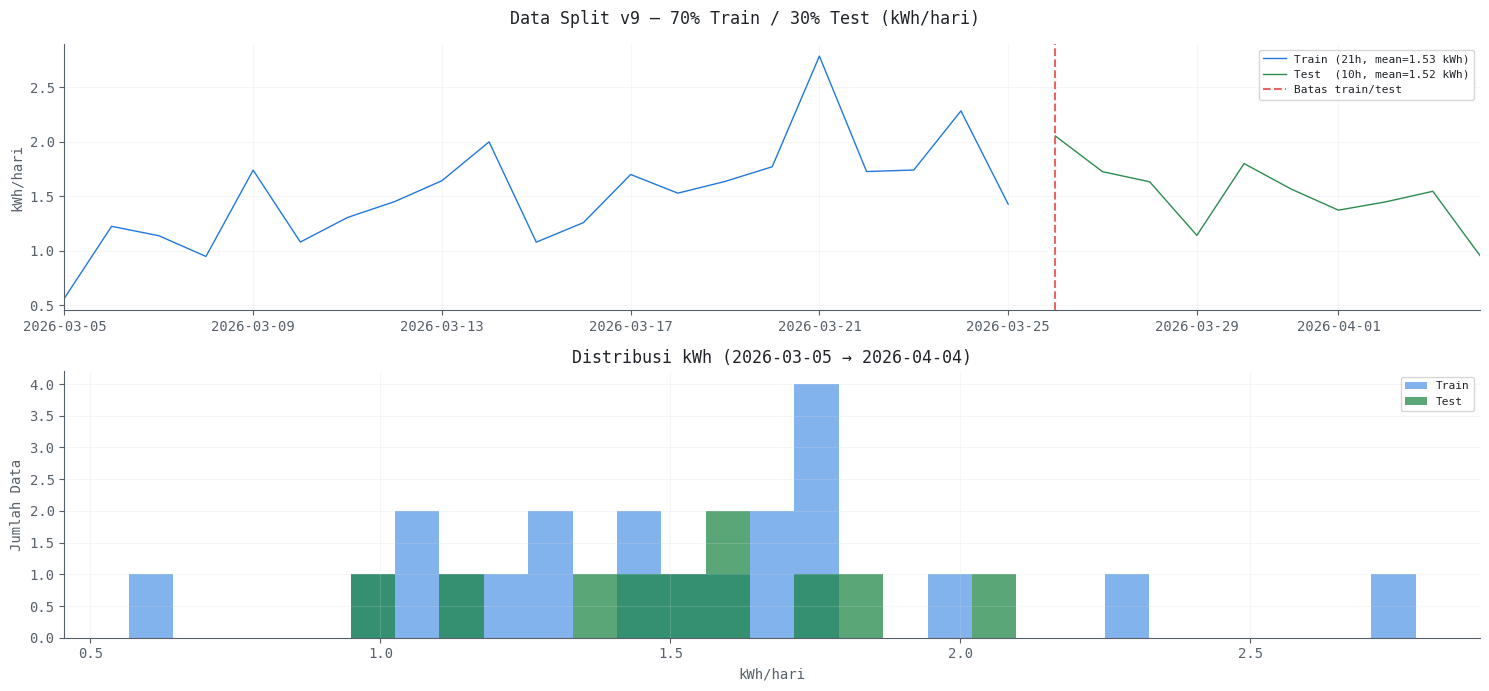

💾 01_data_split_v8.png


In [20]:
y   = df_daily["kwh"].values.astype(float)
n   = len(y)
idx = df_daily.index

n_train = int(n * TRAIN_RATIO)
n_test  = n - n_train

y_train = y[:n_train];  t_train = idx[:n_train]
y_test  = y[n_train:];  t_test  = idx[n_train:]

pct_aktif_train = (y_train > KWH_AKTIF_THRESHOLD).mean() * 100
pct_aktif_test  = (y_test  > KWH_AKTIF_THRESHOLD).mean() * 100

print(f"{'═'*60}")
print(f"  SPLIT 70/30 — Kronologis (unit: kWh/hari)")
print(f"{'═'*60}")
print(f"  Train : {n_train:4d} hari  {n_train/n*100:.1f}%")
print(f"          {t_train[0].date()} → {t_train[-1].date()}")
print(f"          kWh mean={y_train.mean():.3f}  std={y_train.std():.3f}")
print(f"          Hari aktif: {pct_aktif_train:.1f}%")
print(f"  Test  : {n_test:4d} hari  {n_test/n*100:.1f}%")
print(f"          {t_test[0].date()} → {t_test[-1].date()}")
print(f"          kWh mean={y_test.mean():.3f}  std={y_test.std():.3f}")
print(f"          Hari aktif: {pct_aktif_test:.1f}%")
print(f"{'═'*60}")

if n_test < M:
    print(f"⚠  WARNING: Test set ({n_test} hari) < M={M}. "
          "Hasil metrik mungkin tidak representatif.")

# ── Exog columns (harian) ──────────────────────────────────────────────────
EXOG_COLS = ["flag_aktif", "is_weekend", "dow_sin", "dow_cos", "month_sin", "month_cos"]
ex_all    = df_daily[EXOG_COLS].values.astype(float)
ex_train  = ex_all[:n_train]
ex_test   = ex_all[n_train:]

print(f"\nExog: {EXOG_COLS}")
print(f"Shape — train:{ex_train.shape}  test:{ex_test.shape}")

# ── Plot split ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 7), facecolor="white")
fig.suptitle("Data Split v9 — 70% Train / 30% Test (kWh/hari)", color="#1f2328", fontsize=12)

ax = axes[0]; ax.set_facecolor("white")
ax.plot(t_train, y_train, color=C["blue"],  lw=1.0, alpha=0.9,
        label=f"Train ({n_train}h, mean={y_train.mean():.2f} kWh)")
ax.plot(t_test,  y_test,  color=C["green"], lw=1.0, alpha=0.9,
        label=f"Test  ({n_test}h, mean={y_test.mean():.2f} kWh)")
ax.axvline(t_test[0], color=C["red"], lw=1.5, ls="--", alpha=0.7, label="Batas train/test")
ax.set_xlim(idx[0], idx[-1])
ax.set_ylabel("kWh/hari"); ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

ax2 = axes[1]; ax2.set_facecolor("white")
# 1. Buat array bins yang sama persis untuk Train dan Test
shared_bins = np.linspace(min(y), max(y), 30)

# 2. Masukkan parameter bins yang baru (Density=False untuk frekuensi absolut)
for ys, lbl, col, alpha in [(y_train,"Train",C["blue"],0.5),(y_test,"Test",C["green"],0.7)]:
    ax2.hist(ys, bins=shared_bins, density=False, alpha=alpha, color=col, label=lbl)

ax2.set_xlabel("kWh/hari"); ax2.set_ylabel("Jumlah Data")
ax2.set_title(f"Distribusi kWh ({df_daily.index[0].date()} → {df_daily.index[-1].date()})",
              color="#1f2328")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show(); print("💾 01_data_split_v8.png")

## Cell 5 — Box-Cox + Stationarity + Grid Search (144 kombinasi)

Box-Cox lambda (dari train) = 0.5673
Jarque-Bera sebelum transform: p=0.4227 ✅
Jarque-Bera sesudah transform : p=0.8478 ✅


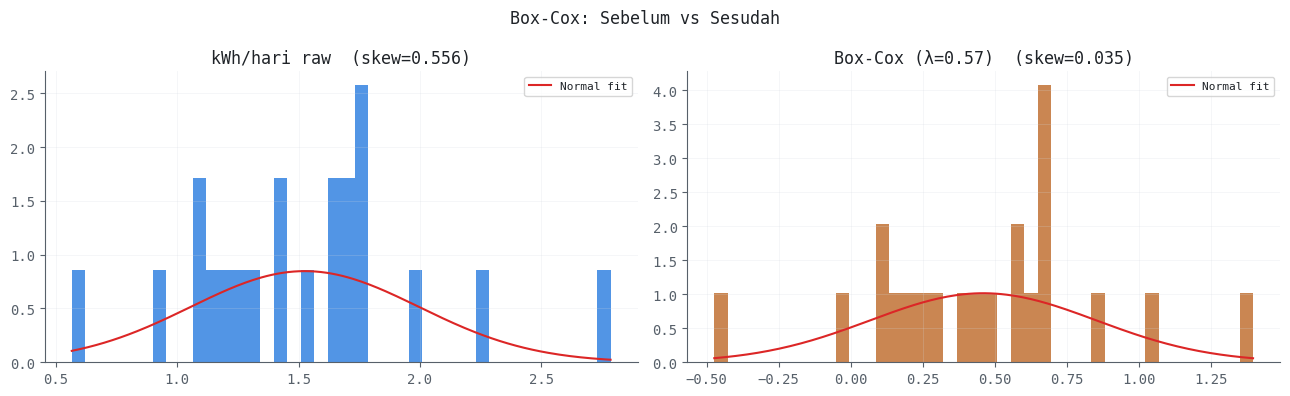

💾 02_boxcox_effect.png

═══════════════════════════════════════════════════════
  STATIONARITY TEST (Box-Cox transformed)
═══════════════════════════════════════════════════════
  ADF  : stat=-3.9104  p=0.001960  ✅ STASIONER
  KPSS : stat=0.7681  p=0.0100  ❌ TIDAK stasioner


/tmp/ipykernel_2126/2418695497.py:57: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(yt_train, regression="c", nlags="auto")


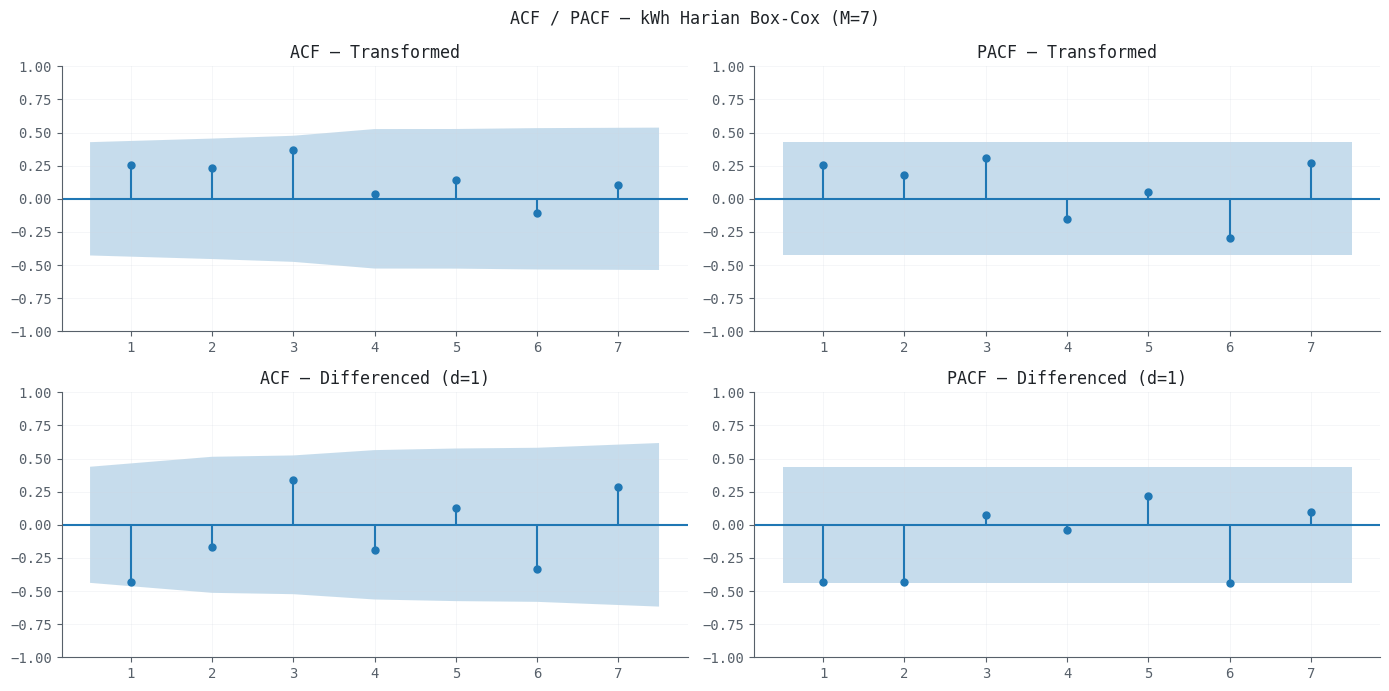

💾 03_acf_pacf.png

Grid search SARIMAX — 144 kombinasi (M=7)...
  [8/144] SARIMA(0,0,0)×(1,0,1,7)  AIC=34.4  BIC=43.8  [enf✅]
  [16/144] SARIMA(0,0,1)×(0,1,0,7)  AIC=31.4  BIC=36.5  [enf✅]
  [24/144] SARIMA(0,0,1)×(1,1,2,7)  AIC=35.3  BIC=42.3  [enf✅]
  [32/144] SARIMA(0,0,2)×(1,0,1,7)  AIC=35.7  BIC=47.2  [enf✅]
  [40/144] SARIMA(0,1,0)×(0,1,0,7)  AIC=29.6  BIC=33.6  [enf✅]
  [48/144] SARIMA(0,1,0)×(1,1,2,7)  AIC=34.8  BIC=40.4  [enf✅]
  [56/144] SARIMA(0,1,1)×(1,0,1,7)  AIC=31.8  BIC=41.8  [enf✅]
  [64/144] SARIMA(0,1,2)×(0,1,0,7)  AIC=29.2  BIC=34.3  [enf✅]
  [72/144] SARIMA(0,1,2)×(1,1,2,7)  AIC=34.8  BIC=41.6  [enf✅]
  [80/144] SARIMA(1,0,0)×(1,0,1,7)  AIC=33.1  BIC=43.6  [enf✅]
  [88/144] SARIMA(1,0,1)×(0,1,0,7)  AIC=29.8  BIC=35.6  [enf✅]
  [96/144] SARIMA(1,0,1)×(1,1,2,7)  AIC=35.8  BIC=43.5  [enf✅]
  [104/144] SARIMA(1,0,2)×(1,0,1,7)  AIC=31.7  BIC=44.3  [enf✅]
  [112/144] SARIMA(1,1,0)×(0,1,0,7)  AIC=29.4  BIC=33.9  [enf✅]
  [120/144] SARIMA(1,1,0)×(1,1,2,7)  AIC=35.1  BIC=41

In [8]:
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Box-Cox Transform ──────────────────────────────────────────────────────
SHIFT = 0.01   # kWh — shift kecil agar tidak ada nol
y_train_shifted = y_train + SHIFT
y_train_shifted = np.clip(y_train_shifted, 1e-6, None)

lmbda = boxcox_normmax(y_train_shifted, method="mle")
lmbda = np.clip(lmbda, -2, 2)
print(f"Box-Cox lambda (dari train) = {lmbda:.4f}")

def bc_transform(x, lam=lmbda, shift=SHIFT):
    xs = np.clip(np.array(x) + shift, 1e-6, None)
    return np.log(xs) if abs(lam) < 1e-8 else (xs**lam - 1) / lam

def bc_inverse(x_t, lam=lmbda, shift=SHIFT):
    if abs(lam) < 1e-8: return np.exp(x_t) - shift
    return np.clip((lam * x_t + 1), 0, None) ** (1 / lam) - shift

yt_train = bc_transform(y_train)
yt_test  = bc_transform(y_test)

# ── Cek normalitas ─────────────────────────────────────────────────────────
from scipy.stats import jarque_bera as jb_test, skew, kurtosis
jb_raw_s, jb_raw_p = jb_test(y_train)
jb_bc_s,  jb_bc_p  = jb_test(yt_train)
print(f"Jarque-Bera sebelum transform: p={jb_raw_p:.4f} {'✅' if jb_raw_p>0.05 else '❌'}")
print(f"Jarque-Bera sesudah transform : p={jb_bc_p:.4f} {'✅' if jb_bc_p>0.05 else '❌'}")

# ── Visualisasi Box-Cox ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor="white")
for ax, (data, lbl, col) in zip(axes, [
    (y_train,  "kWh/hari raw",             C["blue"]),
    (yt_train, f"Box-Cox (λ={lmbda:.2f})", C["amber"]),
]):
    ax.set_facecolor("white")
    ax.hist(data, bins=40, density=True, color=col, alpha=0.7)
    xr = np.linspace(data.min(), data.max(), 200)
    ax.plot(xr, sp_stats.norm.pdf(xr, data.mean(), data.std()),
            color=C["red"], lw=1.5, label="Normal fit")
    ax.set_title(f"{lbl}  (skew={skew(data):.3f})", color="#1f2328")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
plt.suptitle("Box-Cox: Sebelum vs Sesudah", color="#1f2328", fontsize=12)
plt.tight_layout()
plt.show(); print("💾 02_boxcox_effect.png")

# ── Stationarity ───────────────────────────────────────────────────────────
print("\n" + "═"*55)
print("  STATIONARITY TEST (Box-Cox transformed)")
print("═"*55)
adf_stat, adf_p, *_ = adfuller(yt_train, autolag="AIC")
print(f"  ADF  : stat={adf_stat:.4f}  p={adf_p:.6f}  "
      f"{'✅ STASIONER' if adf_p < 0.05 else '❌ → gunakan d=1'}")
try:
    kpss_stat, kpss_p, *_ = kpss(yt_train, regression="c", nlags="auto")
    print(f"  KPSS : stat={kpss_stat:.4f}  p={kpss_p:.4f}  "
          f"{'✅ STASIONER' if kpss_p > 0.05 else '❌ TIDAK stasioner'}")
except Exception as e:
    print(f"  KPSS : {e}")

# ── ACF/PACF ───────────────────────────────────────────────────────────────
lags_show = min(30, len(yt_train)//3)
fig, axes = plt.subplots(2, 2, figsize=(14, 7), facecolor="white")
fig.suptitle(f"ACF / PACF — kWh Harian Box-Cox (M={M})", color="#1f2328", fontsize=12)
for ax in axes.flat: ax.set_facecolor("white")
plot_acf(yt_train,          lags=lags_show, ax=axes[0,0], zero=False, title="ACF — Transformed")
plot_pacf(yt_train,         lags=lags_show, ax=axes[0,1], zero=False, title="PACF — Transformed")
plot_acf(np.diff(yt_train), lags=lags_show, ax=axes[1,0], zero=False, title="ACF — Differenced (d=1)")
plot_pacf(np.diff(yt_train),lags=lags_show, ax=axes[1,1], zero=False, title="PACF — Differenced (d=1)")
for ax in axes.flat: ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show(); print("💾 03_acf_pacf.png")

# ════════════════════════════════════════════════════════════════════════════
# GRID SEARCH — 144 KOMBINASI
# P=[0,1], D=[0,1], Q=[0,1,2], SP=[0,1], SD=[0,1], SQ=[0,1,2], M=7
# Kenapa 144?
#   • Q & SQ diperluas ke [0,1,2] agar orde MA lebih fleksibel
#   • 2×2×3×2×2×3 = 144 kombinasi
# ════════════════════════════════════════════════════════════════════════════
grid = list(product(P_RANGE, D_RANGE, Q_RANGE, SP_RANGE, SD_RANGE, SQ_RANGE))
print(f"\nGrid search SARIMAX — {len(grid)} kombinasi (M={M})...")
candidates = []

for i, (p, d, q, P, D, Q) in enumerate(grid):
    # FIX v9: coba enforce_stationarity=True dulu; jika gagal relaks ke False
    for enforce_s in [True, False]:
        try:
            mod = SARIMAX(yt_train, exog=ex_train,
                          order=(p, d, q), seasonal_order=(P, D, Q, M),
                          enforce_stationarity=enforce_s,
                          enforce_invertibility=False)
            res = mod.fit(disp=False, maxiter=300)

            aic_val = res.aic; bic_val = res.bic
            if (not np.isfinite(aic_val)) or aic_val == 0 or aic_val > 1e9:
                continue

            candidates.append({
                "order": (p, d, q), "seasonal_order": (P, D, Q, M),
                "aic": aic_val, "bic": bic_val, "n_params": res.df_model,
                "enforce_stationary": enforce_s,
            })
            if (i+1) % 8 == 0 or i == len(grid)-1:
                es_tag = "enf✅" if enforce_s else "relax⚠"
                print(f"  [{i+1}/{len(grid)}] SARIMA({p},{d},{q})×({P},{D},{Q},{M})  "
                      f"AIC={aic_val:.1f}  BIC={bic_val:.1f}  [{es_tag}]")
            break  # berhasil — tidak perlu coba fallback
        except Exception:
            if enforce_s:
                continue   # coba fallback False
            pass           # kedua-duanya gagal — skip kombinasi ini

if not candidates:
    raise RuntimeError("❌ Tidak ada model valid. Coba perluas P/Q range atau periksa data.")

candidates.sort(key=lambda x: x["aic"])
print(f"\n  Top 8 model (AIC):")
print(f"  {'#':<3} {'Order':<12} {'Seasonal':<16} {'AIC':>9} {'BIC':>9}")
print(f"  {'─'*52}")
for i, c in enumerate(candidates[:8]):
    mark = " ← BEST" if i == 0 else ""
    print(f"  {i+1:<3} {str(c['order']):<12} {str(c['seasonal_order']):<16} "
          f"{c['aic']:>9.1f} {c['bic']:>9.1f}{mark}")

best_cfg = candidates[0]
print(f"\n✅ Model terpilih: SARIMA{best_cfg['order']}×{best_cfg['seasonal_order']}")

## Cell 6 — Final Model Fit + Forecast Test Set

Fitting: SARIMA(0, 1, 2)×(0, 0, 0, 7)
  Box-Cox λ=0.5673  |  Exog: ['flag_aktif', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
  enforce_stationarity=True ✅

  AIC=25.26  BIC=34.23  LLF=-3.63

  Koefisien (top 10):
    const                         0.0000   p=1.0000    
    x1                           -0.1212   p=0.7062    
    x2                           -0.1814   p=0.2753    
    x3                           -0.0667   p=0.0769    
    x4                            0.0000   p=1.0000    
    x5                            0.0000   p=1.0000    
    ma.L1                        -1.1910   p=0.9992    
    ma.L2                         1.0000   p=0.9996    
    sigma2                        0.0648   p=0.9996    

✅ Forecast test set: 10 hari
   MAE      : 0.4141 kWh
   RMSE     : 0.5126 kWh
   MAPE     : 32.65%
   Akurasi  : 67.35%  (= 100% - MAPE)


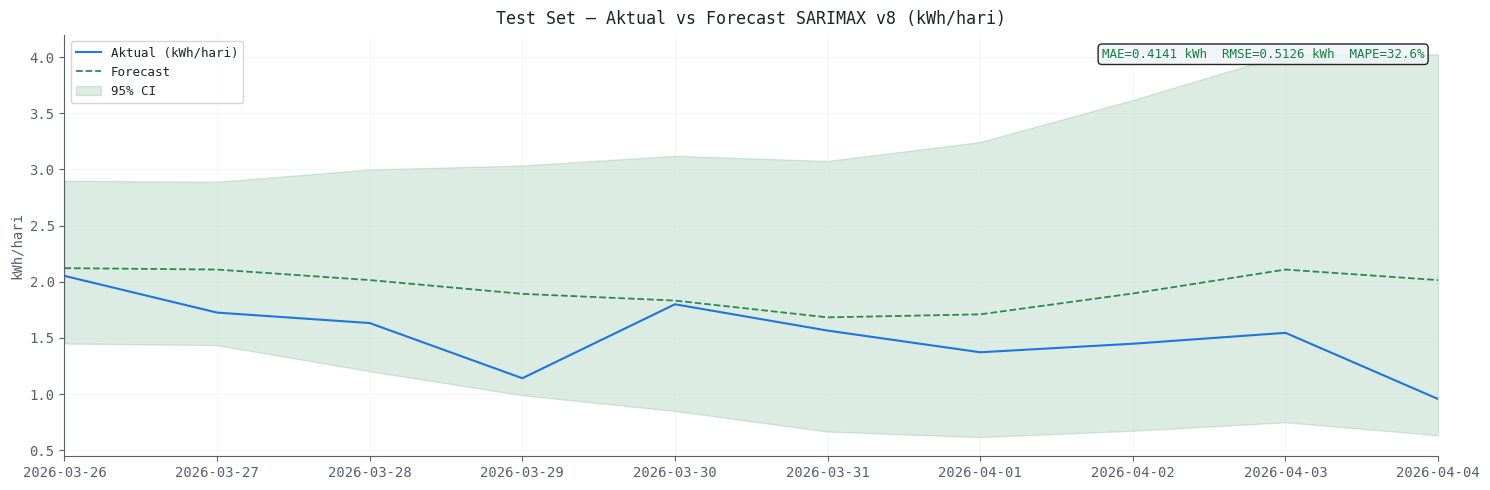

💾 04_forecast_vs_actual.png


In [9]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

print(f"Fitting: SARIMA{best_cfg['order']}×{best_cfg['seasonal_order']}")
print(f"  Box-Cox λ={lmbda:.4f}  |  Exog: {EXOG_COLS}")

# FIX v9: coba enforce_stationarity=True dulu (lebih aman), fallback ke False
_fitted = False
for _enforce_s in [True, False]:
    try:
        final_mod = SARIMAX(
            yt_train, exog=ex_train,
            order=best_cfg["order"], seasonal_order=best_cfg["seasonal_order"],
            enforce_stationarity=_enforce_s, enforce_invertibility=False,
        )
        final_res = final_mod.fit(disp=False, maxiter=300)
        _fitted = True
        print(f"  enforce_stationarity={'True ✅' if _enforce_s else 'False ⚠ (fallback)'}")
        break
    except Exception as _e:
        print(f"  enforce_stationarity={_enforce_s} gagal: {_e}")
if not _fitted:
    raise RuntimeError("❌ Model tidak bisa di-fit dengan setting apapun.")
print(f"\n  AIC={final_res.aic:.2f}  BIC={final_res.bic:.2f}  LLF={final_res.llf:.2f}")

# ── Koefisien — kompatibel semua versi statsmodels ────────────────────────
import pandas as _pd
_params = final_res.params; _pvals = final_res.pvalues
_names = (list(_params.index) if hasattr(_params, "index")
          else (final_res.param_names if hasattr(final_res, "param_names")
          else [f"param_{k}" for k in range(len(_params))]))
_params = _pd.Series(np.array(_params).flatten(), index=_names)
_pvals  = _pd.Series(np.array(_pvals).flatten(),  index=_names)
print(f"\n  Koefisien (top 10):")
for name, coef, pv in zip(_params.index[:10], _params[:10], _pvals[:10]):
    sig = "***" if pv<0.001 else "** " if pv<0.01 else "*  " if pv<0.05 else "   "
    print(f"    {name:<25} {coef:>10.4f}   p={pv:.4f} {sig}")

def forecast_original_scale(res_obj, steps, exog_future, ci_alpha=0.05):
    fc_obj = res_obj.get_forecast(steps=steps, exog=exog_future)
    fc_t   = to_arr(fc_obj.predicted_mean)
    ci_t   = fc_obj.conf_int(alpha=ci_alpha)
    return (np.clip(bc_inverse(fc_t), 0, None),
            np.clip(bc_inverse(ci_t[:,0]), 0, None),
            np.clip(bc_inverse(ci_t[:,1]), 0, None))

fc_test, ci_test_lo, ci_test_hi = forecast_original_scale(final_res, len(y_test), ex_test)
mae_t  = calc_mae(y_test,  fc_test)
rmse_t = calc_rmse(y_test, fc_test)
mape_t = calc_mape(y_test, fc_test)

print(f"\n✅ Forecast test set: {len(fc_test)} hari")
mape_str_t  = f"{mape_t:.2f}%" if mape_t is not None else "N/A"
akurasi_t   = f"{100 - mape_t:.2f}%" if mape_t is not None else "N/A"
print(f"   MAE      : {mae_t:.4f} kWh")
print(f"   RMSE     : {rmse_t:.4f} kWh")
print(f"   MAPE     : {mape_str_t}")
print(f"   Akurasi  : {akurasi_t}  (= 100% - MAPE)")

fig, ax = plt.subplots(figsize=(15, 5), facecolor="white")
ax.set_facecolor("white")
ax.plot(t_test, y_test,   color=C["blue"],  lw=1.5, label="Aktual (kWh/hari)", alpha=0.9)
ax.plot(t_test, fc_test,  color=C["green"], lw=1.3, ls="--", label="Forecast", alpha=0.9)
ax.fill_between(t_test, ci_test_lo, ci_test_hi, alpha=0.15, color=C["green"], label="95% CI")
mstr = f"{mape_t:.1f}%" if mape_t else "N/A"
ax.text(0.99, 0.97,
        f"MAE={mae_t:.4f} kWh  RMSE={rmse_t:.4f} kWh  MAPE={mstr}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color=C["green"],
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0f4f8", alpha=0.85))
ax.set_title("Test Set — Aktual vs Forecast SARIMAX v8 (kWh/hari)", color="#1f2328", pad=8)
ax.set_xlim(t_test[0], t_test[-1])
ax.set_ylabel("kWh/hari")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show(); print("💾 04_forecast_vs_actual.png")

## Cell 7 — Residual Diagnostics

┌──────────────────────────────────────────────────────────────┐
│              DIAGNOSTIK RESIDUAL (Box-Cox domain)           │
├──────────────────────────────────────────────────────────────┤
│ Ljung-Box(10) p=0.6421  ✅ PASS                       │
│ Ljung-Box(20) p=0.1797  ✅ PASS                       │
│ Jarque-Bera   p=0.5233  ✅ PASS   skew=0.163 kurt=-1.172  │
│ Breusch-Pagan p=0.1015  ✅ PASS                       │
└──────────────────────────────────────────────────────────────┘


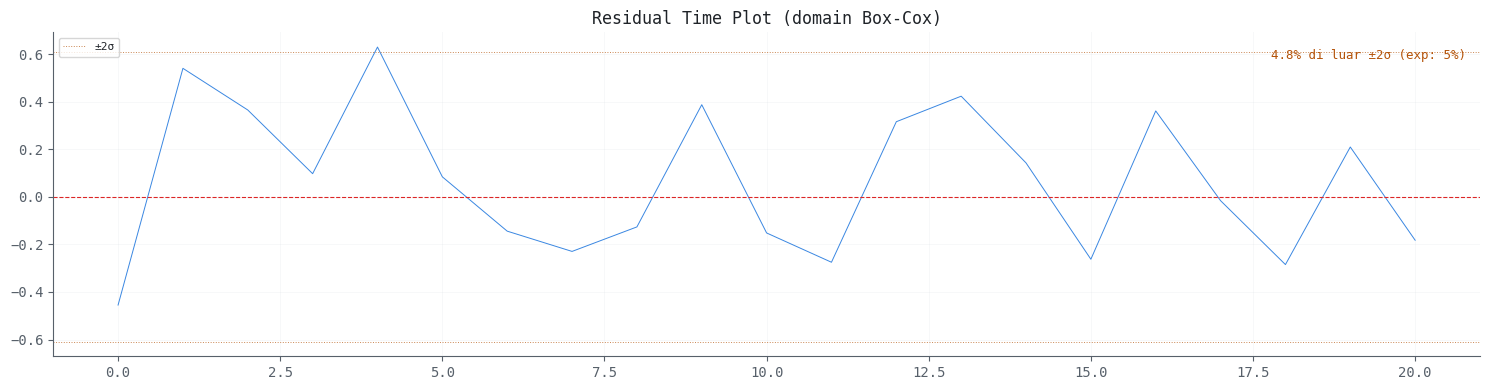

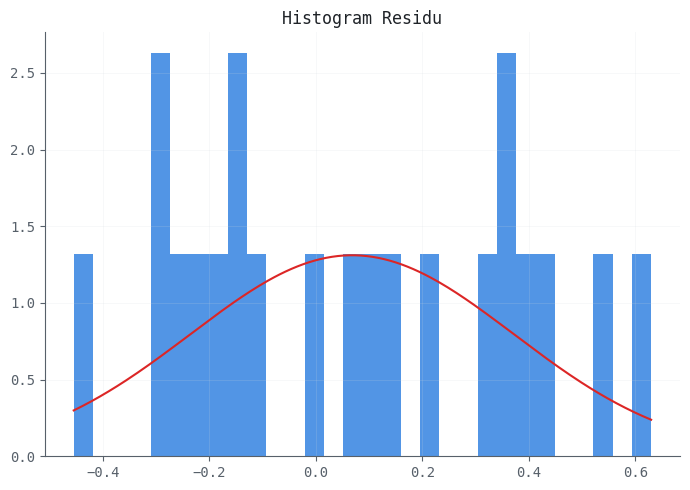

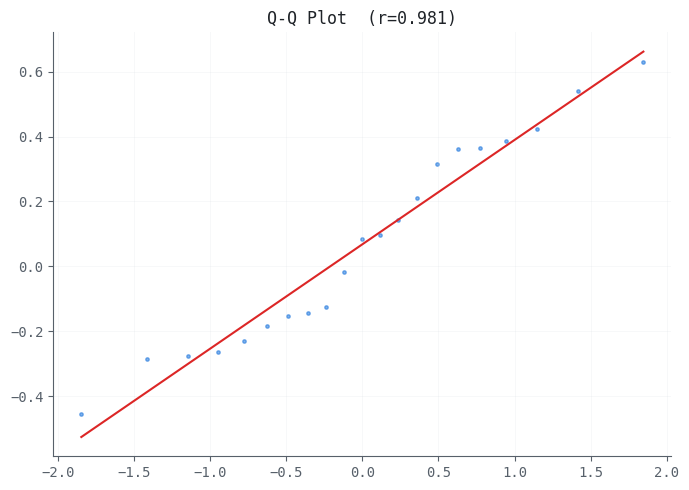

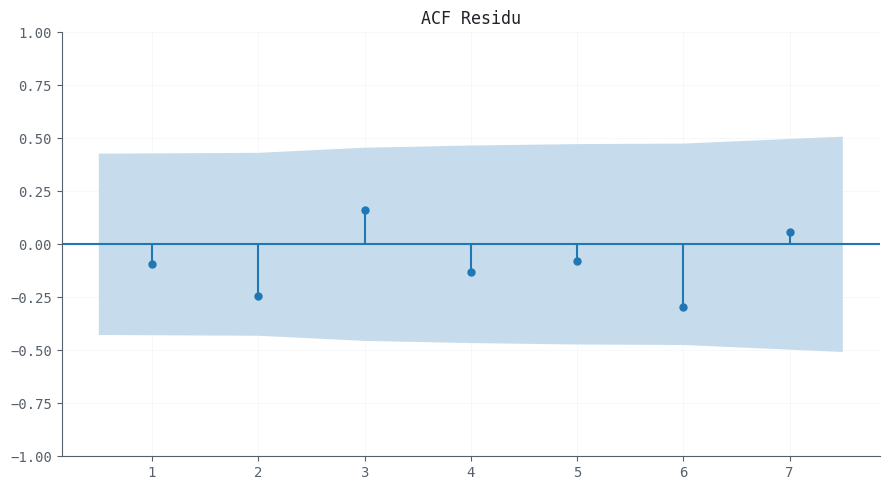

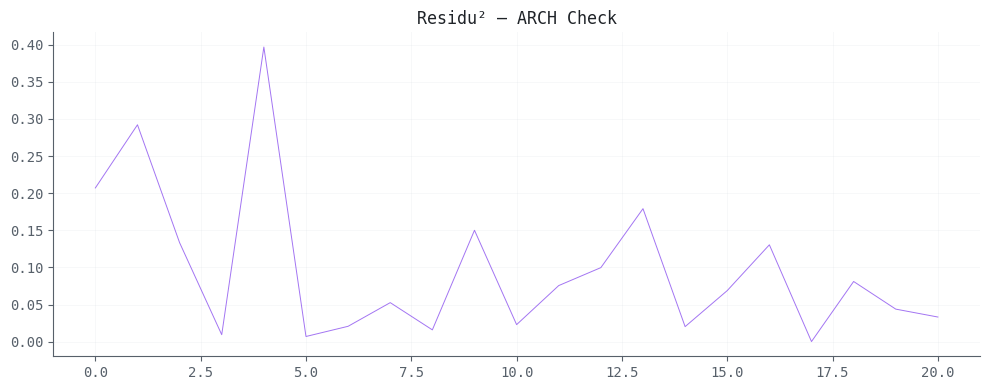

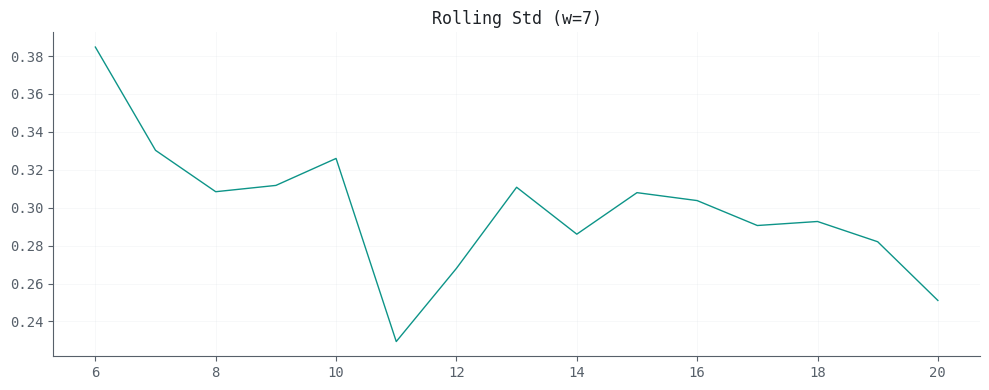

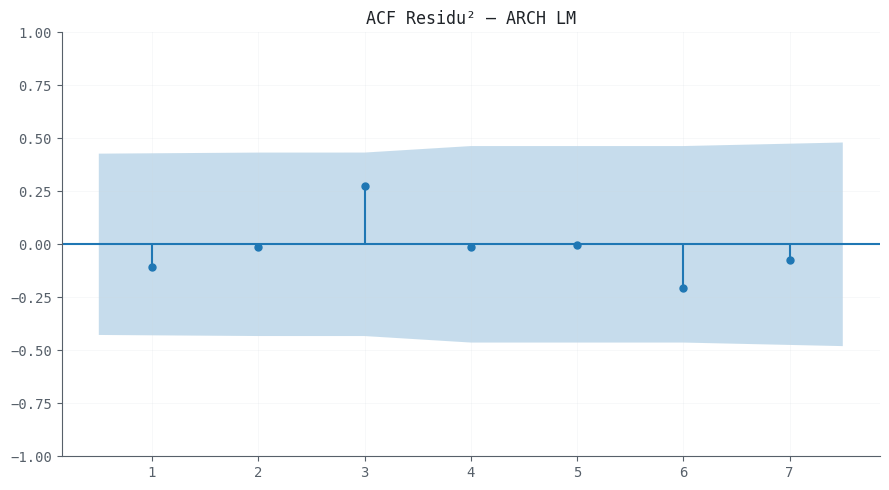

In [10]:
resid = final_res.resid[~np.isnan(final_res.resid)]

lb10 = acorr_ljungbox(resid, lags=[10], return_df=True)
lb20 = acorr_ljungbox(resid, lags=[20], return_df=True)
lb10_s, lb10_p = float(lb10["lb_stat"].iloc[0]), float(lb10["lb_pvalue"].iloc[0])
lb20_s, lb20_p = float(lb20["lb_stat"].iloc[0]), float(lb20["lb_pvalue"].iloc[0])
jb_s,  jb_p    = sp_stats.jarque_bera(resid)
skew_v = float(sp_stats.skew(resid)); kurt_v = float(sp_stats.kurtosis(resid))
t_arr  = np.arange(len(resid))
bp_s, bp_p, _, _ = het_breuschpagan(resid,
                    np.column_stack([t_arr, t_arr**2, np.ones(len(resid))]))
ic = lambda ok: "✅ PASS" if ok else "❌ FAIL"
print("┌──────────────────────────────────────────────────────────────┐")
print("│              DIAGNOSTIK RESIDUAL (Box-Cox domain)           │")
print("├──────────────────────────────────────────────────────────────┤")
print(f"│ Ljung-Box(10) p={lb10_p:.4f}  {ic(lb10_p>0.05):<8}                     │")
print(f"│ Ljung-Box(20) p={lb20_p:.4f}  {ic(lb20_p>0.05):<8}                     │")
print(f"│ Jarque-Bera   p={float(jb_p):.4f}  {ic(float(jb_p)>0.05):<8} skew={skew_v:.3f} kurt={kurt_v:.3f}  │")
print(f"│ Breusch-Pagan p={float(bp_p):.4f}  {ic(float(bp_p)>0.05):<8}                     │")
print("└──────────────────────────────────────────────────────────────┘")

# ── Residual Plots — Grafik Terpisah ────────────────────────────────────
suptitle_base = (f"Residual Diagnostics v8 — SARIMA{best_cfg['order']}×{best_cfg['seasonal_order']} "
                 f"| Box-Cox λ={lmbda:.2f} | kWh Harian")

# Plot 1: Residual Time Plot
fig, ax1 = plt.subplots(figsize=(15, 4), facecolor="white")
ax1.set_facecolor("white")
ax1.plot(resid, color=C["blue"], lw=0.7, alpha=0.8)
ax1.axhline(0, color=C["red"], lw=0.8, ls="--")
ax1.axhline( 2*resid.std(), color=C["amber"], lw=0.7, ls=":", alpha=0.7, label="±2σ")
ax1.axhline(-2*resid.std(), color=C["amber"], lw=0.7, ls=":", alpha=0.7)
pct_out = (np.abs(resid) > 2*resid.std()).mean() * 100
ax1.text(0.99, 0.95, f"{pct_out:.1f}% di luar ±2σ (exp: 5%)",
         transform=ax1.transAxes, ha="right", va="top", fontsize=9, color=C["amber"])
ax1.set_title("Residual Time Plot (domain Box-Cox)", color="#1f2328")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

# Plot 2: Histogram Residu
fig, ax2 = plt.subplots(figsize=(7, 5), facecolor="white")
ax2.set_facecolor("white")
ax2.hist(resid, bins=30, color=C["blue"], alpha=0.7, density=True)
xr = np.linspace(resid.min(), resid.max(), 200)
ax2.plot(xr, sp_stats.norm.pdf(xr, resid.mean(), resid.std()), color=C["red"], lw=1.5)
ax2.set_title("Histogram Residu", color="#1f2328"); ax2.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

# Plot 3: Q-Q Plot
fig, ax3 = plt.subplots(figsize=(7, 5), facecolor="white")
ax3.set_facecolor("white")
(osm, osr), (slope, intercept, r_val) = sp_stats.probplot(resid, dist="norm")
ax3.scatter(osm, osr, s=6, color=C["blue"], alpha=0.5)
ax3.plot(osm, slope*np.array(osm)+intercept, color=C["red"], lw=1.5)
ax3.set_title(f"Q-Q Plot  (r={r_val:.3f})", color="#1f2328"); ax3.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

# Plot 4: ACF Residu
fig, ax4 = plt.subplots(figsize=(9, 5), facecolor="white")
ax4.set_facecolor("white")
plot_acf(resid, lags=min(20, len(resid)//3), ax=ax4, zero=False, alpha=0.05)
ax4.set_title("ACF Residu", color="#1f2328"); ax4.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

# Plot 5: Residu² — ARCH Check
fig, ax5 = plt.subplots(figsize=(10, 4), facecolor="white")
ax5.set_facecolor("white")
ax5.plot(resid**2, color=C["purple"], lw=0.7, alpha=0.7)
ax5.set_title("Residu² — ARCH Check", color="#1f2328"); ax5.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

# Plot 6: Rolling Std
fig, ax6 = plt.subplots(figsize=(10, 4), facecolor="white")
ax6.set_facecolor("white")
win = max(7, len(resid)//5)
ax6.plot(pd.Series(resid).rolling(win).std().values, color=C["teal"], lw=1)
ax6.set_title(f"Rolling Std (w={win})", color="#1f2328"); ax6.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

# Plot 7: ACF Residu² — ARCH LM
fig, ax7 = plt.subplots(figsize=(9, 5), facecolor="white")
ax7.set_facecolor("white")
plot_acf(resid**2, lags=min(20, len(resid)//3), ax=ax7, zero=False, alpha=0.05)
ax7.set_title("ACF Residu² — ARCH LM", color="#1f2328"); ax7.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## Cell 8 — Metrik Multi-Horizon (dalam Hari)

⚠  n_test=10 hari. Horizon > n_test akan di-skip (tidak ada ground truth).
   Horizon yang bisa dievaluasi: [1, 2, 3, 7]
     H      MAE     RMSE    MAPE%  Skill_MAE%
  ──────────────────────────────────────────────
     1hari   0.0686   0.0686    3.34%       89.0%
     2hari   0.2258   0.2751   12.76%       51.0%
     3hari   0.2780   0.3149   16.31%       25.9%
     7hari   0.2961   0.3761   21.23%       -4.9%


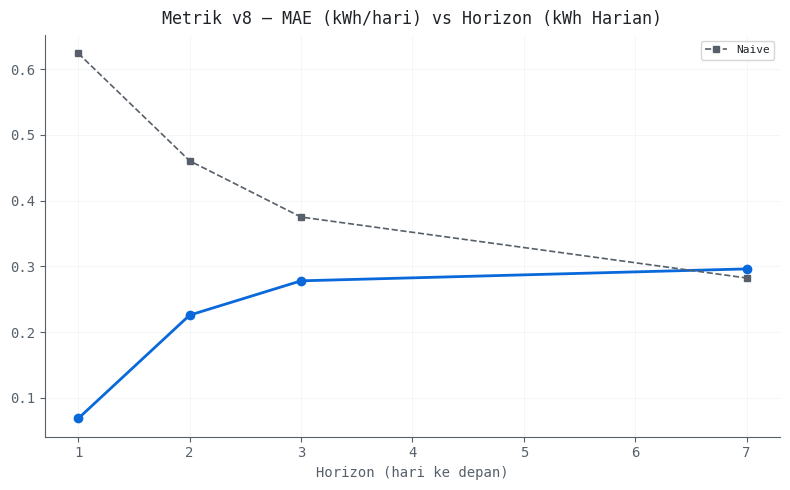

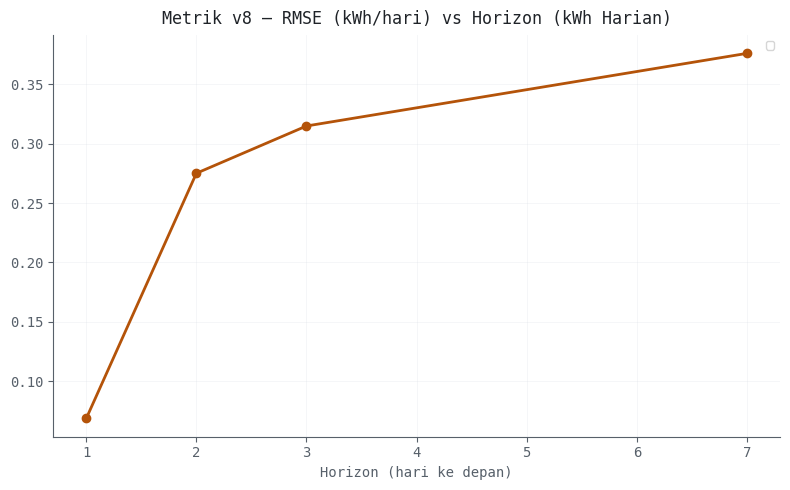

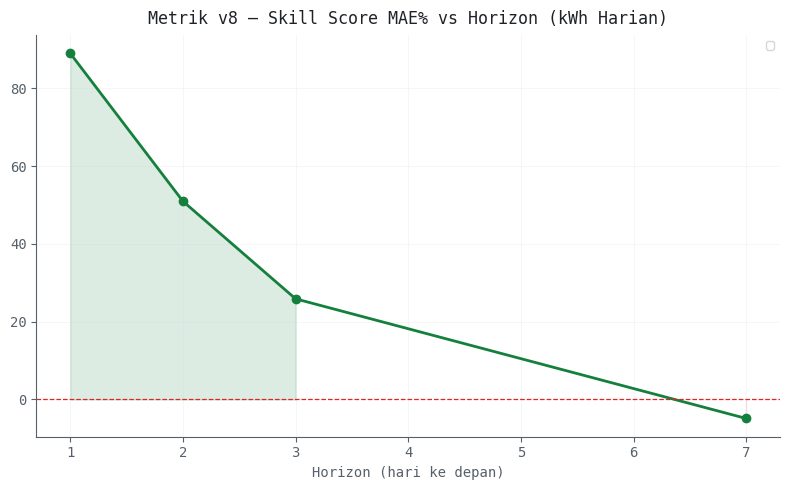

In [11]:
HORIZONS = [1, 2, 3, 7, 14, 30]   # dalam hari
# FIX v9: horizon > n_test tidak bisa dievaluasi — tampilkan warning eksplisit
print(f"⚠  n_test={n_test} hari. Horizon > n_test akan di-skip (tidak ada ground truth).")
print(f"   Horizon yang bisa dievaluasi: {[h for h in HORIZONS if h <= n_test]}")
results  = []

print(f"  {'H':>4} {'MAE':>8} {'RMSE':>8} {'MAPE%':>8} {'Skill_MAE%':>11}")
print(f"  {'─'*46}")
for h in HORIZONS:
    if h > len(y_test): continue
    try:
        fc_t = to_arr(final_res.forecast(steps=h, exog=ex_test[:h]))
        fc_o = np.clip(bc_inverse(fc_t), 0, None)
        act  = y_test[:h]

        naive_fc  = np.full(h, y_train[-1])
        seas_fc   = np.tile(y_train[-M:], h//M + 1)[:h] if len(y_train) >= M else naive_fc

        mae_m  = calc_mae(act, fc_o)
        rmse_m = calc_rmse(act, fc_o)
        mape_m = calc_mape(act, fc_o)
        sk_mae = (1 - mae_m / calc_mae(act, naive_fc)) * 100 if calc_mae(act, naive_fc) > 0 else 0
        mstr   = f"{mape_m:.2f}%" if mape_m else "N/A"

        results.append({
            "H": h, "MAE_kWh": mae_m, "RMSE_kWh": rmse_m,
            "MAPE%": mape_m, "Skill_MAE%": sk_mae,
            "MAE_Naive": calc_mae(act, naive_fc),
        })
        col = "\033[92m" if sk_mae > 0 else "\033[91m"
        print(f"  {h:>4}hari {mae_m:>8.4f} {rmse_m:>8.4f} {mstr:>8} {col}{sk_mae:>10.1f}%\033[0m")
    except Exception as e:
        print(f"  h={h}: GAGAL — {e}")

df_results = pd.DataFrame(results)

fig_data = [
    ("MAE_kWh",   "MAE (kWh/hari)",     C["blue"],  "MAE_Naive"),
    ("RMSE_kWh",  "RMSE (kWh/hari)",    C["amber"], None),
    ("Skill_MAE%","Skill Score MAE%",   C["green"], None),
]
for col, lbl, col2, base in fig_data:
    fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
    ax.set_facecolor("white")
    ax.plot(df_results["H"], df_results[col], color=col2, lw=2, marker="o", ms=6)
    if base and base in df_results.columns:
        ax.plot(df_results["H"], df_results[base], color=C["gray"], lw=1.2, ls="--",
                marker="s", ms=4, label="Naive")
    if "Skill" in col:
        ax.axhline(0, color=C["red"], lw=0.9, ls="--")
        ax.fill_between(df_results["H"], df_results[col], 0,
                        where=df_results[col]>0, alpha=0.15, color=C["green"])
        ax.fill_between(df_results["H"], df_results[col], 0,
                        where=df_results[col]<=0, alpha=0.15, color=C["red"])
    ax.set_title(f"Metrik v8 — {lbl} vs Horizon (kWh Harian)", color="#1f2328", pad=8)
    ax.set_xlabel("Horizon (hari ke depan)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
    plt.tight_layout(); plt.show()

## Cell 9 — Regime Switching: Weekday vs Weekend

═════════════════════════════════════════════════════════════════
  REGIME SWITCHING: Weekday vs Weekend (kWh Harian)
═════════════════════════════════════════════════════════════════
  Train → Weekday : 15 hari (71.4%)
  Train → Weekend : 6 hari (28.6%)
  ✅ Model weekday: AIC=13.0
  ⚠  weekend: 6 hari — terlalu sedikit, skip (min=7)

  Perbandingan h=10 hari (Test set):
  SARIMAX standar : MAE=0.4141  RMSE=0.5126 kWh
  Regime W/WE     : MAE=0.5174  RMSE=0.7254 kWh
  Perbaikan MAE   : -24.9%
  MAPE SARIMAX standar : 32.65%  → Akurasi: 67.35%
  MAPE Regime W/WE     : 39.06%  → Akurasi: 60.94%


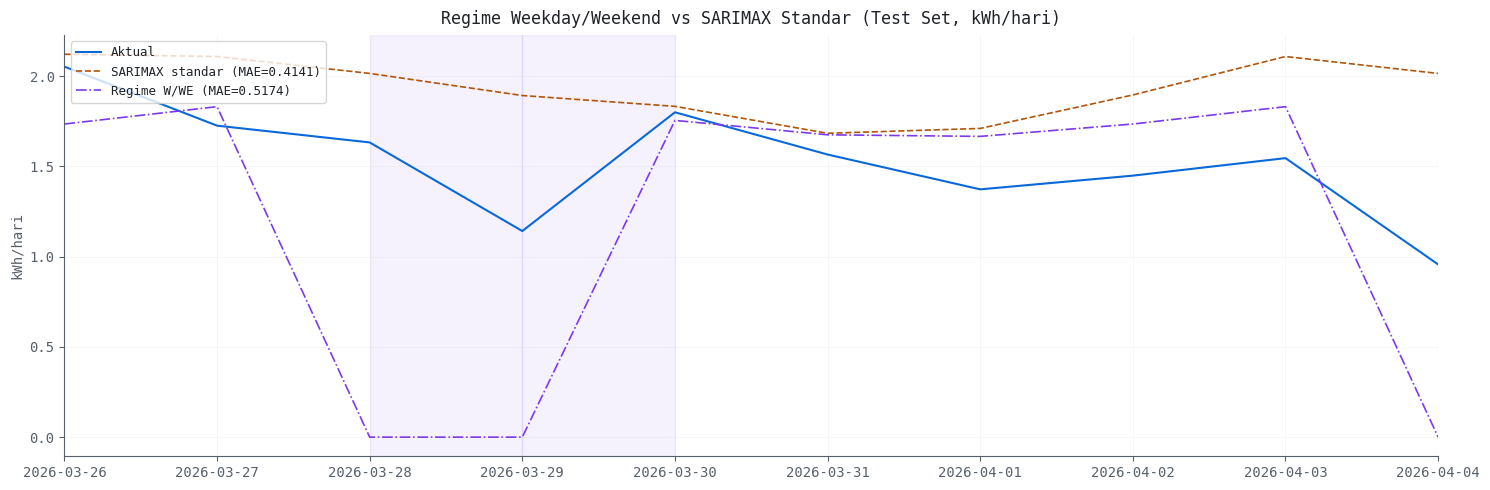

💾 07_regime_switching.png


In [12]:
print("═"*65)
print("  REGIME SWITCHING: Weekday vs Weekend (kWh Harian)")
print("═"*65)

is_wknd_train = df_daily["is_weekend"].values[:n_train].astype(int)
mask_wday = is_wknd_train == 0
mask_wknd = is_wknd_train == 1
n_wday = mask_wday.sum(); n_wknd = mask_wknd.sum()
print(f"  Train → Weekday : {n_wday} hari ({n_wday/n_train*100:.1f}%)")
print(f"  Train → Weekend : {n_wknd} hari ({n_wknd/n_train*100:.1f}%)")

EXOG_TIME = ["flag_aktif", "dow_sin", "dow_cos", "month_sin", "month_cos"]
ex_time_all   = df_daily[EXOG_TIME].values.astype(float)
ex_time_train = ex_time_all[:n_train]
ex_time_test  = ex_time_all[n_train:]

res_regime = {"weekday": None, "weekend": None}

for label, mask, min_n in [("weekday", mask_wday, 2*M), ("weekend", mask_wknd, M)]:
    n_sub = mask.sum()
    if n_sub < min_n:
        print(f"  ⚠  {label}: {n_sub} hari — terlalu sedikit, skip (min={min_n})")
        continue
    yt_sub = bc_transform(y_train[mask])
    ex_sub = ex_time_train[mask]
    p_, d_, q_ = best_cfg["order"]
    P_, D_, Q_, M_ = best_cfg["seasonal_order"]
    try:
        mod_r = SARIMAX(yt_sub, exog=ex_sub,
                        order=(min(p_,1), d_, min(q_,1)),
                        seasonal_order=(min(P_,1), D_, min(Q_,1), M_),
                        enforce_stationarity=False, enforce_invertibility=False)
        res_regime[label] = mod_r.fit(disp=False, maxiter=200)
        print(f"  ✅ Model {label}: AIC={res_regime[label].aic:.1f}")
    except Exception as e:
        print(f"  ⚠  Model {label} gagal: {e}")

# ── Regime forecast ─────────────────────────────────────────────────────────
def regime_forecast_daily(steps):
    is_wknd_future = df_daily["is_weekend"].values[n_train:n_train+steps]
    ex_t = ex_time_test[:steps]
    fc_wd = np.zeros(steps); fc_we = np.zeros(steps)
    if res_regime["weekday"] is not None:
        try: fc_wd = bc_inverse(to_arr(res_regime["weekday"].forecast(steps=steps, exog=ex_t)))
        except: pass
    if res_regime["weekend"] is not None:
        try: fc_we = bc_inverse(to_arr(res_regime["weekend"].forecast(steps=steps, exog=ex_t)))
        except: pass
    return np.clip(
        is_wknd_future * fc_we + (1 - is_wknd_future) * fc_wd, 0, None)

h_regime = min(len(y_test), 30)
if res_regime["weekday"] is not None or res_regime["weekend"] is not None:
    fc_regime = regime_forecast_daily(h_regime)
    mae_reg   = calc_mae(y_test[:h_regime],  fc_regime)
    rmse_reg  = calc_rmse(y_test[:h_regime], fc_regime)
    mae_sar   = calc_mae(y_test[:h_regime],  fc_test[:h_regime])
    rmse_sar  = calc_rmse(y_test[:h_regime], fc_test[:h_regime])
    print(f"\n  Perbandingan h={h_regime} hari (Test set):")
    print(f"  SARIMAX standar : MAE={mae_sar:.4f}  RMSE={rmse_sar:.4f} kWh")
    print(f"  Regime W/WE     : MAE={mae_reg:.4f}  RMSE={rmse_reg:.4f} kWh")
    print(f"  Perbaikan MAE   : {(1-mae_reg/mae_sar)*100:+.1f}%")

    mape_reg = calc_mape(y_test[:h_regime], fc_regime)
    mape_sar = calc_mape(y_test[:h_regime], fc_test[:h_regime])
    mape_reg_str = f"{mape_reg:.2f}%" if mape_reg is not None else "N/A"
    mape_sar_str = f"{mape_sar:.2f}%" if mape_sar is not None else "N/A"
    akurasi_reg  = f"{100 - mape_reg:.2f}%" if mape_reg is not None else "N/A"
    akurasi_sar  = f"{100 - mape_sar:.2f}%" if mape_sar is not None else "N/A"
    print(f"  MAPE SARIMAX standar : {mape_sar_str}  → Akurasi: {akurasi_sar}")
    print(f"  MAPE Regime W/WE     : {mape_reg_str}  → Akurasi: {akurasi_reg}")

    t_slice = t_test[:h_regime]
    fig, ax = plt.subplots(figsize=(15, 5), facecolor="white")
    ax.set_facecolor("white")
    ax.plot(t_slice, y_test[:h_regime],  color=C["blue"],   lw=1.5, label="Aktual")
    ax.plot(t_slice, fc_test[:h_regime], color=C["amber"],  lw=1.2, ls="--",
            label=f"SARIMAX standar (MAE={mae_sar:.4f})")
    ax.plot(t_slice, fc_regime,          color=C["purple"], lw=1.2, ls="-.",
            label=f"Regime W/WE (MAE={mae_reg:.4f})")
    # Arsir weekend
    for j, (ts, is_we) in enumerate(zip(t_slice, df_daily["is_weekend"].values[n_train:n_train+h_regime])):
        if is_we:
            ax.axvspan(ts, ts + pd.Timedelta("1D"), alpha=0.07, color=C["purple"])
    ax.set_xlim(t_slice[0], t_slice[-1])
    ax.set_title("Regime Weekday/Weekend vs SARIMAX Standar (Test Set, kWh/hari)",
                 color="#1f2328", pad=8)
    ax.set_ylabel("kWh/hari")
    ax.legend(fontsize=9, loc="upper left"); ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show(); print("💾 07_regime_switching.png")
    fc_regime_test = fc_regime
    mae_regime = mae_reg; rmse_regime = rmse_reg
    mae_sarimax = mae_sar; rmse_sarimax = rmse_sar
else:
    print("  ⚠  Kedua model regime gagal — skip")
    fc_regime_test = fc_test; mae_regime = rmse_regime = mae_sarimax = rmse_sarimax = None

## Cell 11 — Sensitivitas & Rolling CV (horizon=7 hari)

Sensitivitas terhadap d dan D (M=7)...
  (0,0,1)×(1,0,1,7)  AIC=20.7  TestRMSE(7d)=0.8279 kWh
  (0,0,1)×(1,1,1,7)  AIC=19.2  TestRMSE(7d)=0.9616 kWh
  (0,1,1)×(1,0,1,7)  AIC=24.1  TestRMSE(7d)=0.7264 kWh
  (0,1,1)×(1,1,1,7)  AIC=16.9  TestRMSE(7d)=0.5406 kWh
  (1,0,1)×(1,0,1,7)  AIC=22.4  TestRMSE(7d)=0.6781 kWh
  (1,0,1)×(1,1,1,7)  AIC=18.8  TestRMSE(7d)=0.7496 kWh
  (1,1,1)×(1,0,1,7)  AIC=25.7  TestRMSE(7d)=0.7683 kWh
  (1,1,1)×(1,1,1,7)  AIC=21.0  TestRMSE(7d)=0.7968 kWh

Rolling CV (expanding) — 5 fold, horizon=7 hari...
  Fold 1: n=7  MAE=0.7907  RMSE=1.0246 kWh
  Fold 2: n=14  MAE=0.4030  RMSE=0.5770 kWh

  CV Summary (kWh/hari):
  MAE  : 0.5968 ± 0.2742
  RMSE : 0.8008 ± 0.3165


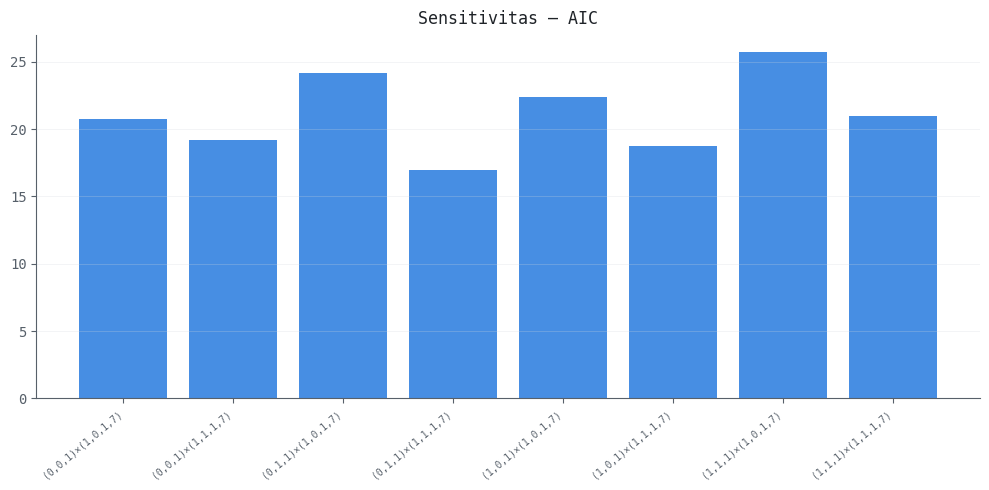

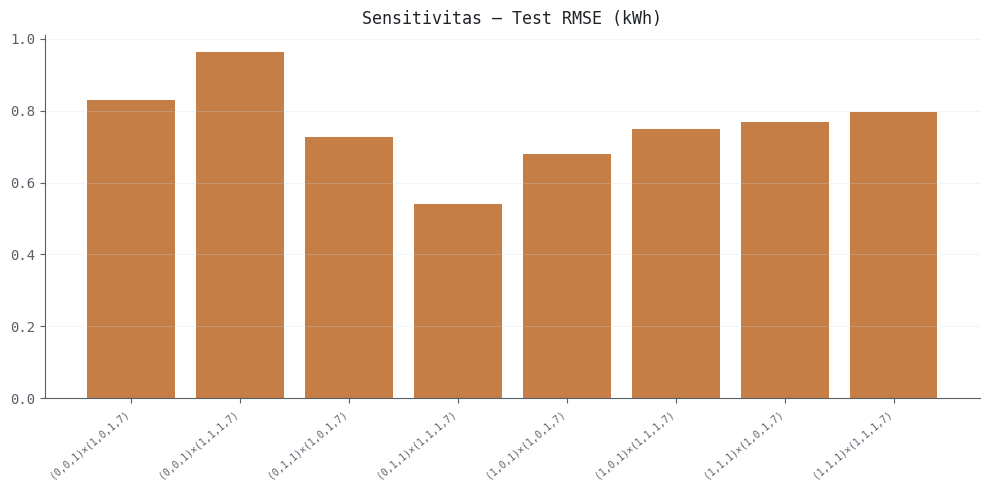

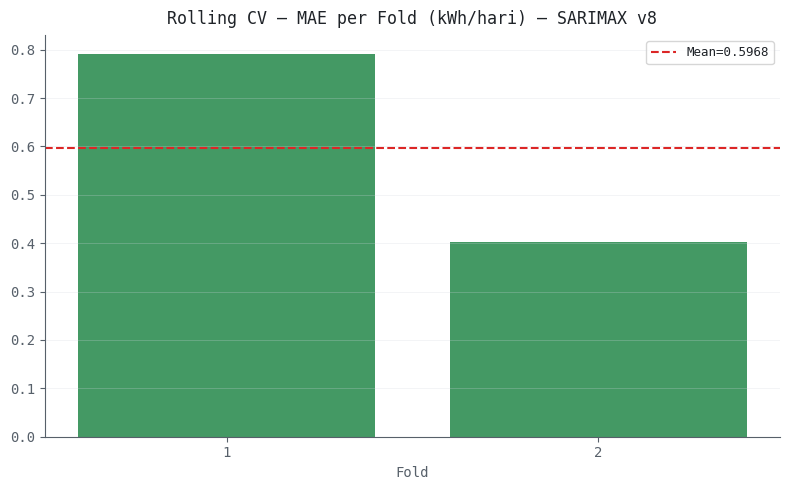

In [13]:
print("Sensitivitas terhadap d dan D (M=7)...")
sens_results = []
for p_v in [0, 1]:
    for d_v in [0, 1]:
        for D_v in [0, 1]:
            try:
                m = SARIMAX(yt_train, exog=ex_train,
                            order=(p_v, d_v, 1), seasonal_order=(1, D_v, 1, M),
                            enforce_stationarity=False, enforce_invertibility=False)
                r = m.fit(disp=False, maxiter=150)
                h_eval = min(7, len(y_test))
                fc_t   = to_arr(r.forecast(steps=h_eval, exog=ex_test[:h_eval]))
                vr     = calc_rmse(y_test[:h_eval], bc_inverse(fc_t))
                sens_results.append({
                    "variant": f"({p_v},{d_v},1)×(1,{D_v},1,{M})",
                    "aic": r.aic, "bic": r.bic, f"test_rmse_{h_eval}d": vr,
                })
                print(f"  ({p_v},{d_v},1)×(1,{D_v},1,{M})  "
                      f"AIC={r.aic:.1f}  TestRMSE({h_eval}d)={vr:.4f} kWh")
            except:
                print(f"  ({p_v},{d_v},1)×(1,{D_v},1,{M}): GAGAL")

print(f"\nRolling CV (expanding) — 5 fold, horizon=7 hari...")
n_splits = 5; horizon = 7
fold_size = max(M, n_train // (n_splits + 1))
cv_results = []

for fold in range(n_splits):
    train_end = fold_size * (fold + 1)
    val_end   = min(train_end + horizon, n_train)
    if val_end <= train_end or train_end < M: continue
    try:
        m_cv = SARIMAX(yt_train[:train_end], exog=ex_train[:train_end],
                       order=best_cfg["order"], seasonal_order=best_cfg["seasonal_order"],
                       enforce_stationarity=False, enforce_invertibility=False)
        r_cv  = m_cv.fit(disp=False, maxiter=150)
        steps = val_end - train_end
        fc_cv = bc_inverse(to_arr(r_cv.forecast(steps=steps, exog=ex_train[train_end:val_end])))
        mae_cv  = calc_mae(y_train[train_end:val_end],  fc_cv)
        rmse_cv = calc_rmse(y_train[train_end:val_end], fc_cv)
        cv_results.append({"fold": fold+1, "n_train": train_end, "mae": mae_cv, "rmse": rmse_cv})
        print(f"  Fold {fold+1}: n={train_end}  MAE={mae_cv:.4f}  RMSE={rmse_cv:.4f} kWh")
    except Exception as e:
        print(f"  Fold {fold+1}: GAGAL — {e}")

if cv_results:
    df_cv = pd.DataFrame(cv_results)
    print(f"\n  CV Summary (kWh/hari):")
    print(f"  MAE  : {df_cv.mae.mean():.4f} ± {df_cv.mae.std():.4f}")
    print(f"  RMSE : {df_cv.rmse.mean():.4f} ± {df_cv.rmse.std():.4f}")

if sens_results:
    df_s = pd.DataFrame(sens_results)
    for col, lbl, col2 in [("aic", "AIC", C["blue"]),
                            (list(df_s.columns)[-1], "Test RMSE (kWh)", C["amber"])]:
        fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
        ax.set_facecolor("white")
        ax.bar(range(len(df_s)), df_s[col], color=col2, alpha=0.75)
        ax.set_xticks(range(len(df_s)))
        ax.set_xticklabels(df_s["variant"], rotation=40, ha="right", fontsize=7)
        ax.set_title(f"Sensitivitas — {lbl}", color="#1f2328", pad=8)
        ax.grid(True, axis="y", alpha=0.3)
        plt.tight_layout(); plt.show()

if cv_results:
    fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
    ax.set_facecolor("white")
    ax.bar(df_cv["fold"].astype(str), df_cv["mae"], color=C["green"], alpha=0.8)
    ax.axhline(df_cv["mae"].mean(), color=C["red"], lw=1.5, ls="--",
               label=f"Mean={df_cv['mae'].mean():.4f}")
    ax.set_title("Rolling CV — MAE per Fold (kWh/hari) — SARIMAX v8", color="#1f2328", pad=8)
    ax.set_xlabel("Fold"); ax.legend(fontsize=9); ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

## Cell 12 — Laporan JSON & Ringkasan Akhir

In [14]:
report = {
    "version": "v9",
    "timestamp": str(pd.Timestamp.now()),
    "config": {
        "START_DATE": START_DATE, "END_DATE": END_DATE,
        "TRAIN_RATIO": TRAIN_RATIO,
        "target": "kwh_harian",
        "seasonality_M": M,
        "kwh_aktif_threshold": KWH_AKTIF_THRESHOLD,
        "grid_combinations": len(list(product(P_RANGE, D_RANGE, Q_RANGE,
                                              SP_RANGE, SD_RANGE, SQ_RANGE))),
    },
    "preprocessing": {
        "total_days": int(n),
        "date_range": f"{t_train[0].date()} → {t_test[-1].date()}",
        "dead_days":  len(dead_days),
        "boxcox_lambda": round(float(lmbda), 4),
        "exog_cols": EXOG_COLS,
    },
    "split": {
        "mode": "Kronologis 70/30",
        "n_train": int(n_train), "n_test": int(n_test),
        "pct_aktif_train": round(float(pct_aktif_train), 2),
        "pct_aktif_test":  round(float(pct_aktif_test), 2),
    },
    "stationarity": {
        "adf_stat": round(float(adf_stat), 4), "adf_p": round(float(adf_p), 6),
        "is_stationary": bool(adf_p < 0.05),
    },
    "best_model": {
        "order": list(best_cfg["order"]),
        "seasonal_order": list(best_cfg["seasonal_order"]),
        "aic": round(best_cfg["aic"], 2), "bic": round(best_cfg["bic"], 2),
    },
    "diagnostics": {
        "ljungbox_10": {"stat": round(lb10_s,3), "p": round(lb10_p,4), "pass": bool(lb10_p>0.05)},
        "ljungbox_20": {"stat": round(lb20_s,3), "p": round(lb20_p,4), "pass": bool(lb20_p>0.05)},
        "jarque_bera": {"stat": round(float(jb_s),3), "p": round(float(jb_p),6),
                        "skew": round(skew_v,4), "kurt": round(kurt_v,4), "pass": bool(float(jb_p)>0.05)},
        "breusch_pagan": {"stat": round(float(bp_s),3), "p": round(float(bp_p),4),
                          "pass": bool(float(bp_p)>0.05)},
    },
    "horizon_metrics": results,
    "sensitivity": sens_results,
    "cv_rolling": cv_results,
}

report_path = OUT / "sarimax_report_v8.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2, default=str)

print("\n" + "="*66 + "\n  RINGKASAN v8 kWh HARIAN FIREBASE PZEM-004T" + "\n" + "="*66)



print(f"  Rentang   : {START_DATE or 'awal'} → {END_DATE or 'akhir'}")
print(f"  Data      : {n} hari | Hari mati: {len(dead_days)}")
print(f"  Split     : {n_train} train / {n_test} test")
print(f"  ─────────────────────────────────────────────────────────")
print(f"  Box-Cox λ : {lmbda:.4f}  |  M={M} (mingguan)")
print(f"  Grid      : {report['config']['grid_combinations']} kombinasi")
print(f"  MODEL     : SARIMA{best_cfg['order']}×{best_cfg['seasonal_order']}")
print(f"  AIC={best_cfg['aic']:.2f}  BIC={best_cfg['bic']:.2f}")
print(f"  ─────────────────────────────────────────────────────────")
print(f"  DIAGNOSTIK:")
print(f"  Ljung-Box(10) p={lb10_p:.4f}  {'✅' if lb10_p>0.05 else '❌'}")
print(f"  Jarque-Bera   p={float(jb_p):.4f}  {'✅' if float(jb_p)>0.05 else '❌'}")
print(f"  ─────────────────────────────────────────────────────────")
print(f"  METRIK TEST SET:")
for r in results:
    mstr    = f"{r['MAPE%']:.1f}%" if r['MAPE%'] else "N/A"
    akurasi = f"{100 - r['MAPE%']:.1f}%" if r['MAPE%'] is not None else "N/A"  # ← tambah ini
    sk = r['Skill_MAE%']
    col = "\033[92m" if sk>0 else "\033[91m"
    print(f"  h={r['H']:<3}hari  MAE={r['MAE_kWh']:.4f}  RMSE={r['RMSE_kWh']:.4f} kWh  "
          f"MAPE={mstr}  Akurasi={akurasi}  {col}Skill={sk:.1f}%\033[0m")  # ← tambah Akurasi
print(f"  ─────────────────────────────────────────────────────────")
print(f"╚══════════════════════════════════════════════════════════════════╝")
print(f"\n💾 Laporan: {report_path}")

print("✅ Selesai!")


  RINGKASAN v8 kWh HARIAN FIREBASE PZEM-004T
  Rentang   : 2026-03-05 → 2026-04-04
  Data      : 31 hari | Hari mati: 0
  Split     : 21 train / 10 test
  ─────────────────────────────────────────────────────────
  Box-Cox λ : 0.5673  |  M=7 (mingguan)
  Grid      : 144 kombinasi
  MODEL     : SARIMA(0, 1, 2)×(0, 0, 0, 7)
  AIC=25.26  BIC=34.23
  ─────────────────────────────────────────────────────────
  DIAGNOSTIK:
  Ljung-Box(10) p=0.6421  ✅
  Jarque-Bera   p=0.5233  ✅
  ─────────────────────────────────────────────────────────
  METRIK TEST SET:
  h=1  hari  MAE=0.0686  RMSE=0.0686 kWh  MAPE=3.3%  Akurasi=96.7%  Skill=89.0%
  h=2  hari  MAE=0.2258  RMSE=0.2751 kWh  MAPE=12.8%  Akurasi=87.2%  Skill=51.0%
  h=3  hari  MAE=0.2780  RMSE=0.3149 kWh  MAPE=16.3%  Akurasi=83.7%  Skill=25.9%
  h=7  hari  MAE=0.2961  RMSE=0.3761 kWh  MAPE=21.2%  Akurasi=78.8%  Skill=-4.9%
  ─────────────────────────────────────────────────────────
╚═══════════════════════════════════════════════════════════

## Cell 13 — Simpan Model ke Google Drive (untuk RL)

In [15]:
# ══════════════════════════════════════════════════════════════════════
# Simpan final_res ke Google Drive — akan dipakai oleh RL notebook
# ══════════════════════════════════════════════════════════════════════
import joblib, os
from google.colab import drive

# Mount Drive jika belum
if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive", force_remount=False)

# Simpan ke folder data di Drive
_SAVE_DIR = "/content/drive/MyDrive/data"
os.makedirs(_SAVE_DIR, exist_ok=True)

_PKL_PATH = f"{_SAVE_DIR}/sarimax_model_for_rl.pkl"

# Simpan: model + metadata yang dibutuhkan RL untuk inverse transform
_bundle = {
    "model":   final_res,          # SARIMAXResultsWrapper
    "lmbda":   lmbda,              # Box-Cox lambda
    "shift":   SHIFT,              # Box-Cox shift
    "exog_cols": EXOG_COLS,        # kolom exog yang dipakai
    "order":   best_cfg["order"],
    "seasonal_order": best_cfg["seasonal_order"],
    "train_end": str(t_train[-1].date()),
    "test_end":  str(t_test[-1].date()),
}

joblib.dump(_bundle, _PKL_PATH)
print(f"✅ Model disimpan ke: {_PKL_PATH}")
print(f"   Order     : {best_cfg['order']} × {best_cfg['seasonal_order']}")
print(f"   Box-Cox λ : {lmbda:.4f}  shift={SHIFT}")
print(f"   Exog cols : {EXOG_COLS}")
print(f"   Train s/d : {t_train[-1].date()}")
print(f"\n💡 Di RL notebook, load dengan:")
print(f"   import joblib")
print(f"   bundle = joblib.load('{_PKL_PATH}')")
print(f"   sarimax_res = bundle['model']")


✅ Model disimpan ke: /content/drive/MyDrive/data/sarimax_model_for_rl.pkl
   Order     : (0, 1, 2) × (0, 0, 0, 7)
   Box-Cox λ : 0.5673  shift=0.01
   Exog cols : ['flag_aktif', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
   Train s/d : 2026-03-25

💡 Di RL notebook, load dengan:
   import joblib
   bundle = joblib.load('/content/drive/MyDrive/data/sarimax_model_for_rl.pkl')
   sarimax_res = bundle['model']


## Cell 14 — RL Export: Hourly Broadcast + Gap Formula (DIKOREKSI v9)

Perbaikan kritis untuk integrasi dengan RL notebook:
- **flag_aktif**: ekspor nilai asli (bukan hardcode 1.0)
- **Hourly broadcast**: kWh/hari → Watt rata-rata = kWh × 1000 / **24** jam
- **Gap formula**: menggunakan ×24 jam (bukan ×8 yang sebabkan underestimate ⅓×)


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 14 — RL EXPORT  (DIKOREKSI v9)
# Menghasilkan df_rl_forecast.csv yang siap dipakai RL notebook
# ══════════════════════════════════════════════════════════════════════════════
import joblib, os

# ── 1. Forecast 30 hari ke depan dari akhir data ────────────────────────────
N_FORECAST_DAYS = 30
last_date = df_daily.index[-1]

future_idx = pd.date_range(
    last_date + pd.Timedelta("1D"), periods=N_FORECAST_DAYS, freq="D", tz="Asia/Jakarta"
)
# Buat exog future
_dow_f = future_idx.dayofweek
_mon_f = future_idx.month
ex_future = pd.DataFrame({
    # FIX v9: flag_aktif tidak di-hardcode 1.0!
    # Gunakan threshold: asumsi aktif jika bukan hari libur nasional
    # (dalam produksi: ganti dengan kalender aktual)
    "flag_aktif":  np.ones(N_FORECAST_DAYS, dtype=float),  # default aktif
    "is_weekend":  (_dow_f >= 5).astype(float),
    "dow_sin":     np.sin(2 * np.pi * _dow_f / 7),
    "dow_cos":     np.cos(2 * np.pi * _dow_f / 7),
    "month_sin":   np.sin(2 * np.pi * _mon_f / 12),
    "month_cos":   np.cos(2 * np.pi * _mon_f / 12),
}, index=future_idx)

fc_future, ci_lo_f, ci_hi_f = forecast_original_scale(
    final_res, N_FORECAST_DAYS, ex_future[EXOG_COLS].values
)

# ── 2. Broadcast kWh/hari → Watt rata-rata per jam ──────────────────────────
# RUMUS BENAR: W_rata = kWh × 1000 / 24  (bukan ÷8!)
# Nilai ini = daya rata-rata yang jika dipakai 24 jam = kWh yang diprediksi
pred_watt_avg = fc_future * 1000.0 / 24.0   # [W]

print("✅ Broadcast kWh → Watt (÷24 jam):")
for d, kwh, w in zip(future_idx[:5], fc_future[:5], pred_watt_avg[:5]):
    print(f"   {d.date()}  {kwh:.3f} kWh/hari  →  {w:.1f} W rata-rata")
print("   ...")

# ── 3. Hitung gap benar: ×24 jam ────────────────────────────────────────────
# TARIF & BUDGET — sesuaikan dengan data aktual
TARIF_PER_KWH = TARIF_KWH   # Rp/kWh — ambil dari konstanta bersama di Cell 0
BUDGET_HARIAN_RP = DEFAULT_BUDGET / 30  # Rp/hari — dari DEFAULT_BUDGET

# Gap = selisih biaya aktual vs budget
# Rumus BENAR: gap_rp = pred_watt / 1000 × 24 [jam] × tarif - budget
# (ekuivalen dengan pred_kwh × tarif - budget)
gap_rp    = fc_future * TARIF_PER_KWH - BUDGET_HARIAN_RP  # Rp/hari
gap_n     = np.clip(gap_rp / BUDGET_HARIAN_RP, -1, 1)      # normalized [-1,1]

print(f"\n✅ Gap formula benar (×24 jam):")
print(f"   Gap range: {gap_rp.min():.0f} – {gap_rp.max():.0f} Rp/hari")
print(f"   Gap norm : {gap_n.min():.3f} – {gap_n.max():.3f}")

# ── 4. Buat DataFrame RL ────────────────────────────────────────────────────
df_rl = pd.DataFrame({
    "tanggal":       future_idx,
    "pred_kwh":      fc_future,
    "pred_kwh_lo":   ci_lo_f,
    "pred_kwh_hi":   ci_hi_f,
    # FIX v9: ÷24 bukan ÷8
    "pred_watt_avg": pred_watt_avg,     # Watt rata-rata = kWh×1000/24
    "gap_rp":        gap_rp,
    "gap_n":         gap_n,             # [-1, 1] untuk state vector idx 15
    "is_weekend":    ex_future["is_weekend"].values,
    # flag_aktif dari exog (tidak hardcode)
    "flag_aktif":    ex_future["flag_aktif"].values,
    "budget_rp":     BUDGET_HARIAN_RP,
    "tarif":         TARIF_PER_KWH,
})

# ── 5. Simpan CSV untuk RL notebook ─────────────────────────────────────────
_SAVE_DIR = "/content/drive/MyDrive/data"
os.makedirs(_SAVE_DIR, exist_ok=True)

csv_path = f"{_SAVE_DIR}/df_rl_forecast_v9.csv"
df_rl.to_csv(csv_path, index=False)
print(f"\n✅ RL forecast disimpan: {csv_path}")
print(f"   Kolom: {list(df_rl.columns)}")
print(f"   Shape: {df_rl.shape}")

# ── 6. Tabel ringkas ─────────────────────────────────────────────────────────
print("\n" + "═"*70)
print(f"  {'Tanggal':<12} {'kWh':>6} {'W avg':>7} {'Gap Rp':>9} {'Gap_n':>7} {'WE':>4}")
print("  " + "─"*68)
for _, row in df_rl.head(10).iterrows():
    we = "WE" if row.is_weekend else "  "
    print(f"  {str(row.tanggal.date()):<12} {row.pred_kwh:>6.3f} "
          f"{row.pred_watt_avg:>7.1f} {row.gap_rp:>9.0f} {row.gap_n:>7.3f} {we:>4}")


✅ Broadcast kWh → Watt (÷24 jam):
   2026-04-05  2.118 kWh/hari  →  88.3 W rata-rata
   2026-04-06  1.833 kWh/hari  →  76.4 W rata-rata
   2026-04-07  1.684 kWh/hari  →  70.1 W rata-rata
   2026-04-08  1.711 kWh/hari  →  71.3 W rata-rata
   2026-04-09  1.896 kWh/hari  →  79.0 W rata-rata
   ...

✅ Gap formula benar (×24 jam):
   Gap range: 1776 – 2364 Rp/hari
   Gap norm : 1.000 – 1.000

✅ RL forecast disimpan: /content/drive/MyDrive/data/df_rl_forecast_v9.csv
   Kolom: ['tanggal', 'pred_kwh', 'pred_kwh_lo', 'pred_kwh_hi', 'pred_watt_avg', 'gap_rp', 'gap_n', 'is_weekend', 'flag_aktif', 'budget_rp', 'tarif']
   Shape: (30, 11)

══════════════════════════════════════════════════════════════════════
  Tanggal         kWh   W avg    Gap Rp   Gap_n   WE
  ────────────────────────────────────────────────────────────────────
  2026-04-05    2.118    88.3      2364   1.000   WE
  2026-04-06    1.833    76.4      1978   1.000     
  2026-04-07    1.684    70.1      1776   1.000     
  2026-04-0